# 🛰️ Smart Port System — Dark Vessel Detection
### Multi-Sensor Satellite Fusion | Spatial · Temporal · ML · Behavioral Intelligence
**Pipeline:** SAR + Sentinel-2 optical fusion → anomaly detection → risk scoring → explainable AI

---
**Run cells ONE BY ONE, top to bottom. Never use Runtime → Run All.**

In [ ]:
# ============================================================
# CELL 1 — PROJECT SETUP & IMPORTS
# ============================================================
import os, sys, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from datetime import datetime

# Sklearn
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import BallTree

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Directory structure ──────────────────────────────────────
BASE        = Path('/content/dark_vessel_project')
EXTRACT_DIR = BASE / 'data' / 'extracted'
PROC_DIR    = BASE / 'data' / 'processed'
MODEL_DIR   = BASE / 'models'
RESULT_DIR  = BASE / 'results'
CKPT_FILE   = PROC_DIR / 'checkpoint_detections.pkl'

for d in [EXTRACT_DIR, PROC_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Global helper ────────────────────────────────────────────
def classify_risk(score):
    if score >= 80:   return 'HIGH RISK'
    elif score >= 60: return 'MEDIUM RISK'
    elif score >= 40: return 'LOW-MEDIUM RISK'
    else:             return 'LOW RISK'

print('✅ CELL 1 COMPLETE — libraries loaded, directories ready')
print(f'   Base path : {BASE}')
print(f'   Extract   : {EXTRACT_DIR}')
print(f'   Checkpoint: {CKPT_FILE}')

✅ CELL 1 COMPLETE — libraries loaded, directories ready
   Base path : /content/dark_vessel_project
   Extract   : /content/dark_vessel_project/data/extracted
   Checkpoint: /content/dark_vessel_project/data/processed/checkpoint_detections.pkl


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:", list(uploaded.keys()))

Saving d4bf69d0-47ab-11f1-baee-91ba50dbe6a1.zip to d4bf69d0-47ab-11f1-baee-91ba50dbe6a1.zip
Saving aedc5110-47ab-11f1-8dac-e93bf8b3feba.zip to aedc5110-47ab-11f1-8dac-e93bf8b3feba.zip
Saving a24b9c80-47ab-11f1-8dac-e93bf8b3feba.zip to a24b9c80-47ab-11f1-8dac-e93bf8b3feba.zip
Uploaded files: ['d4bf69d0-47ab-11f1-baee-91ba50dbe6a1.zip', 'aedc5110-47ab-11f1-8dac-e93bf8b3feba.zip', 'a24b9c80-47ab-11f1-8dac-e93bf8b3feba.zip']


In [ ]:
import zipfile, os

extract_path = "/content/dark_vessel_project/data/extracted"
os.makedirs(extract_path, exist_ok=True)

for file in uploaded.keys():
    if file.endswith(".zip"):
        with zipfile.ZipFile(file, "r") as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extracted:", file)

Extracted: d4bf69d0-47ab-11f1-baee-91ba50dbe6a1.zip
Extracted: aedc5110-47ab-11f1-8dac-e93bf8b3feba.zip
Extracted: a24b9c80-47ab-11f1-8dac-e93bf8b3feba.zip


In [ ]:
import os

for root, dirs, files in os.walk("/content/dark_vessel_project/data/extracted"):
    for f in files:
        print(os.path.join(root, f))

/content/dark_vessel_project/data/extracted/sentinel2_vessel_detections_pipev4_202603.csv
/content/dark_vessel_project/data/extracted/sar_vessel_detections_pipev4_20260430.csv
/content/dark_vessel_project/data/extracted/voyages_c4_pipe_v3_20260429.csv
/content/dark_vessel_project/data/extracted/sar_vessel_detections_pipev4_202604.csv
/content/dark_vessel_project/data/extracted/voyages_c4_pipe_v3_202604.csv
/content/dark_vessel_project/data/extracted/sentinel2_vessel_detections_pipev4_202602.csv
/content/dark_vessel_project/data/extracted/sentinel2_vessel_detections_pipev4_20260415.csv
/content/dark_vessel_project/data/extracted/sar_vessel_detections_pipev4_202603.csv


In [ ]:
# ============================================================
# CELL 2 — DISCOVER EXTRACTED CSV FILES
# ============================================================
csv_files = sorted(EXTRACT_DIR.rglob('*.csv'))

if not csv_files:
    print('❌ No CSV files found in', EXTRACT_DIR)
    print('   Upload and extract your GFW zip files first, then re-run this cell.')
else:
    print(f'✅ Found {len(csv_files)} CSV file(s):')
    for i, f in enumerate(csv_files):
        size_mb = f.stat().st_size / 1e6
        print(f'  [{i}] {f.name}  ({size_mb:.1f} MB)')

# ── Classify files by keyword ────────────────────────────────
sar_files  = [f for f in csv_files if 'sar'       in f.name.lower()]
s2_files   = [f for f in csv_files if 'sentinel2' in f.name.lower()]
voy_files  = [f for f in csv_files if 'voyage'    in f.name.lower()]

print(f'\n  SAR files      : {len(sar_files)}')
print(f'  Sentinel-2 files: {len(s2_files)}')
print(f'  Voyage files   : {len(voy_files)}')

if not sar_files and not s2_files:
    print('\n⚠️  Neither SAR nor Sentinel-2 files were auto-detected.')
    print('   Check filenames — they must contain "sar" or "sentinel2".')

✅ Found 8 CSV file(s):
  [0] sar_vessel_detections_pipev4_202603.csv  (20.9 MB)
  [1] sar_vessel_detections_pipev4_202604.csv  (0.0 MB)
  [2] sar_vessel_detections_pipev4_20260430.csv  (0.0 MB)
  [3] sentinel2_vessel_detections_pipev4_202602.csv  (444.0 MB)
  [4] sentinel2_vessel_detections_pipev4_202603.csv  (583.4 MB)
  [5] sentinel2_vessel_detections_pipev4_20260415.csv  (323.5 MB)
  [6] voyages_c4_pipe_v3_202604.csv  (339.5 MB)
  [7] voyages_c4_pipe_v3_20260429.csv  (358.1 MB)

  SAR files      : 3
  Sentinel-2 files: 3
  Voyage files   : 2


In [ ]:
# ============================================================
# CELL 3 — LOAD SAR, SENTINEL-2, AND OPTIONAL VOYAGES
# ============================================================
def safe_load_csvs(file_list, label):
    """Load and concatenate a list of CSV files safely."""
    if not file_list:
        print(f'⚠️  No {label} files to load.')
        return pd.DataFrame()
    frames = []
    for f in file_list:
        try:
            df = pd.read_csv(f, low_memory=False)
            df['_source_file'] = f.name
            frames.append(df)
            print(f'  ✓ {f.name}  → {df.shape}')
        except Exception as e:
            print(f'  ✗ Failed to load {f.name}: {e}')
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

print('Loading SAR files...')
sar_raw = safe_load_csvs(sar_files, 'SAR')

print('\nLoading Sentinel-2 files...')
s2_raw  = safe_load_csvs(s2_files,  'Sentinel-2')

print('\nLoading Voyage files (optional)...')
voy_raw = safe_load_csvs(voy_files, 'Voyages')

print(f'\n✅ CELL 3 COMPLETE')
print(f'   SAR raw        : {sar_raw.shape}')
print(f'   Sentinel-2 raw : {s2_raw.shape}')
if not voy_raw.empty:
    print(f'   Voyages raw    : {voy_raw.shape}')

Loading SAR files...
  ✓ sar_vessel_detections_pipev4_202603.csv  → (107257, 11)
  ✓ sar_vessel_detections_pipev4_202604.csv  → (0, 11)
  ✓ sar_vessel_detections_pipev4_20260430.csv  → (0, 11)

Loading Sentinel-2 files...
  ✓ sentinel2_vessel_detections_pipev4_202602.csv  → (1229767, 29)
  ✓ sentinel2_vessel_detections_pipev4_202603.csv  → (1593755, 29)
  ✓ sentinel2_vessel_detections_pipev4_20260415.csv  → (875990, 29)

Loading Voyage files (optional)...
  ✓ voyages_c4_pipe_v3_202604.csv  → (1419302, 10)
  ✓ voyages_c4_pipe_v3_20260429.csv  → (1497110, 10)

✅ CELL 3 COMPLETE
   SAR raw        : (107257, 11)
   Sentinel-2 raw : (3699512, 29)
   Voyages raw    : (2916412, 10)


In [ ]:
# ============================================================
# CELL 4 — CLEAN & STANDARDISE COLUMNS
# ============================================================
# ── SAR column map ───────────────────────────────────────────
# GFW SAR cols: scene_id, timestamp, lat, lon, presence_score,
#               length_m, mmsi, matching_score, fishing_score, matched_category
def standardise_sar(df):
    if df.empty: return df
    rename = {
        'timestamp'     : 'time',
        'length_m'      : 'length_m_inferred',
        'fishing_score' : 'fishing_score',
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})
    df['source']            = 'Sentinel-1 SAR'
    df['speed_kn_inferred'] = np.nan          # SAR has no speed
    df['confidence']        = df.get('presence_score', pd.Series(dtype=float))
    df['time']              = pd.to_datetime(df['time'], utc=True, errors='coerce')
    return df

# ── Sentinel-2 column map ────────────────────────────────────
# GFW S2 cols: detect_id, scene_id, lat, lon, detect_timestamp,
#              speed_kn_inferred, heading_deg_inferred, length_m_inferred,
#              presence_score, nonvessel_score, cloud_score, ..., mmsi
def standardise_s2(df):
    if df.empty: return df
    rename = {
        'detect_timestamp' : 'time',
        'presence_score'   : 'confidence',
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})
    df['source']        = 'Sentinel-2 Optical'
    df['fishing_score'] = np.nan
    # Strip " UTC" suffix before parsing
    if 'time' in df.columns:
        df['time'] = df['time'].astype(str).str.replace(' UTC', '', regex=False)
        df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')
    return df

sar_clean = standardise_sar(sar_raw.copy())
s2_clean  = standardise_s2(s2_raw.copy())

# ── Common columns kept in final merge ──────────────────────
KEEP_COLS = [
    'source', 'lat', 'lon', 'time',
    'length_m_inferred', 'speed_kn_inferred', 'confidence',
    'fishing_score', 'mmsi', '_source_file'
]

def trim_to_keep(df, keep=KEEP_COLS):
    present = [c for c in keep if c in df.columns]
    return df[present].copy()

sar_trim = trim_to_keep(sar_clean)
s2_trim  = trim_to_keep(s2_clean)

print('✅ CELL 4 COMPLETE — columns standardised')
print('SAR columns :', list(sar_trim.columns))
print('S2  columns :', list(s2_trim.columns))
if not sar_trim.empty:  display(sar_trim.head(2))
if not s2_trim.empty:   display(s2_trim.head(2))

✅ CELL 4 COMPLETE — columns standardised
SAR columns : ['source', 'lat', 'lon', 'time', 'length_m_inferred', 'speed_kn_inferred', 'confidence', 'fishing_score', 'mmsi', '_source_file']
S2  columns : ['source', 'lat', 'lon', 'time', 'length_m_inferred', 'speed_kn_inferred', 'confidence', 'fishing_score', 'mmsi', '_source_file']


,source,lat,lon,time,length_m_inferred,speed_kn_inferred,confidence,fishing_score,mmsi,_source_file
0,Sentinel-1 SAR,15.0732,42.5894,2026-03-01 02:59:51+00:00,298.8764,NaN,0.9961,0.0311,636018944.0000,sar_vessel_detections_pipev4_202603.csv
1,Sentinel-1 SAR,11.8010,43.1999,2026-03-01 03:00:41+00:00,222.8606,NaN,0.9977,0.0129,215282000.0000,sar_vessel_detections_pipev4_202603.csv


,source,lat,lon,time,length_m_inferred,speed_kn_inferred,confidence,fishing_score,mmsi,_source_file
0,Sentinel-2 Optical,-16.7800,44.2792,2026-02-24 07:24:21.289000+00:00,23.7000,0.5800,0.5030,NaN,NaN,sentinel2_vessel_detections_pipev4_202602.csv
1,Sentinel-2 Optical,12.7917,100.8329,2026-02-24 03:54:38.128000+00:00,24.1000,2.3000,0.4820,NaN,NaN,sentinel2_vessel_detections_pipev4_202602.csv


In [ ]:
# ============================================================
# CELL 5 — BUILD detections_df SAFELY
# ============================================================
frames = [df for df in [sar_trim, s2_trim] if not df.empty]

if not frames:
    raise RuntimeError('❌ No data loaded. Cannot build detections_df. Check Cells 2–4.')

detections_df = pd.concat(frames, ignore_index=True)

# ── Basic validation ─────────────────────────────────────────
for required in ['lat', 'lon', 'time', 'source']:
    if required not in detections_df.columns:
        raise ValueError(f'❌ Required column missing: {required}')

# Drop rows without coordinates
before = len(detections_df)
detections_df = detections_df.dropna(subset=['lat', 'lon'])
dropped = before - len(detections_df)

# Ensure numeric types
detections_df['lat']               = pd.to_numeric(detections_df['lat'],               errors='coerce')
detections_df['lon']               = pd.to_numeric(detections_df['lon'],               errors='coerce')
detections_df['confidence']        = pd.to_numeric(detections_df.get('confidence'),     errors='coerce').fillna(0)
detections_df['length_m_inferred'] = pd.to_numeric(detections_df.get('length_m_inferred'), errors='coerce')
detections_df['speed_kn_inferred'] = pd.to_numeric(detections_df.get('speed_kn_inferred'), errors='coerce')
detections_df['fishing_score']     = pd.to_numeric(detections_df.get('fishing_score'),  errors='coerce').fillna(0)

# Initialise flag / score columns
for col in ['conflict', 'rare_area', 'temporal_anomaly',
            'ml_anomaly', 'behavior_anomaly', 'route_anomaly']:
    detections_df[col] = False

detections_df['final_score']     = 0.0
detections_df['boss_score']      = 0.0
detections_df['boss_risk_level'] = 'LOW RISK'

detections_df = detections_df.reset_index(drop=True)

print('✅ CELL 5 COMPLETE — detections_df created')
print(f'   Total rows  : {len(detections_df):,}')
print(f'   Dropped (no coords): {dropped:,}')
print(f'   Sources     : {detections_df["source"].value_counts().to_dict()}')
display(detections_df.head(3))

✅ CELL 5 COMPLETE — detections_df created
   Total rows  : 3,806,769
   Dropped (no coords): 0
   Sources     : {'Sentinel-2 Optical': 3699512, 'Sentinel-1 SAR': 107257}


,source,lat,lon,time,length_m_inferred,speed_kn_inferred,confidence,fishing_score,mmsi,_source_file,conflict,rare_area,temporal_anomaly,ml_anomaly,behavior_anomaly,route_anomaly,final_score,boss_score,boss_risk_level
0,Sentinel-1 SAR,15.0732,42.5894,2026-03-01 02:59:51+00:00,298.8764,NaN,0.9961,0.0311,636018944.0000,sar_vessel_detections_pipev4_202603.csv,False,False,False,False,False,False,0.0000,0.0000,LOW RISK
1,Sentinel-1 SAR,11.8010,43.1999,2026-03-01 03:00:41+00:00,222.8606,NaN,0.9977,0.0129,215282000.0000,sar_vessel_detections_pipev4_202603.csv,False,False,False,False,False,False,0.0000,0.0000,LOW RISK
2,Sentinel-1 SAR,11.6782,43.1167,2026-03-01 03:00:41+00:00,109.8343,NaN,0.9964,0.0129,357132000.0000,sar_vessel_detections_pipev4_202603.csv,False,False,False,False,False,False,0.0000,0.0000,LOW RISK


In [ ]:
# ============================================================
# CELL 6 — CHECKPOINT SAVE / RELOAD
# ============================================================
# To SAVE  → run as-is.
# To RELOAD after a Colab restart → set FORCE_RELOAD = True
#   and make sure Cells 1–2 have been run first.

FORCE_RELOAD = False   # ← flip to True if runtime restarted

if FORCE_RELOAD and CKPT_FILE.exists():
    with open(CKPT_FILE, 'rb') as fh:
        detections_df = pickle.load(fh)
    print(f'✅ Checkpoint LOADED — {len(detections_df):,} rows')

elif 'detections_df' in dir() and not detections_df.empty:
    with open(CKPT_FILE, 'wb') as fh:
        pickle.dump(detections_df, fh, protocol=pickle.HIGHEST_PROTOCOL)
    size_mb = CKPT_FILE.stat().st_size / 1e6
    print(f'✅ Checkpoint SAVED → {CKPT_FILE}  ({size_mb:.1f} MB)')

else:
    print('⚠️  detections_df not found and FORCE_RELOAD=False. Run Cells 1–5 first.')

✅ Checkpoint SAVED → /content/dark_vessel_project/data/processed/checkpoint_detections.pkl  (350.3 MB)


In [ ]:
# ============================================================
# CELL 7 — SAR vs SENTINEL-2 SPATIAL AGREEMENT / CONFLICT
#           Uses BallTree (haversine) — no loops
# ============================================================
assert 'detections_df' in dir(), '❌ Run Cells 1–6 first'

CONFLICT_RADIUS_KM = 1.0          # within 1 km counts as spatial agreement
AGREEMENT_RADIUS_KM = 1.0

sar_mask = detections_df['source'] == 'Sentinel-1 SAR'
s2_mask  = detections_df['source'] == 'Sentinel-2 Optical'

sar_pts = detections_df.loc[sar_mask, ['lat', 'lon']].values
s2_pts  = detections_df.loc[s2_mask,  ['lat', 'lon']].values

if len(sar_pts) > 0 and len(s2_pts) > 0:
    # BallTree expects radians
    sar_rad = np.radians(sar_pts)
    s2_rad  = np.radians(s2_pts)

    tree = BallTree(s2_rad, metric='haversine')
    radius_rad = CONFLICT_RADIUS_KM / 6371.0  # Earth radius km

    # For every SAR point, count nearby S2 points
    counts = tree.query_radius(sar_rad, r=radius_rad, count_only=True)

    # SAR point with NO nearby S2 → conflict (SAR-only detection)
    sar_conflict_mask = counts == 0
    sar_indices = detections_df.index[sar_mask]
    conflict_indices = sar_indices[sar_conflict_mask]

    detections_df.loc[conflict_indices, 'conflict'] = True

    n_conflict = sar_conflict_mask.sum()
    n_agree    = (~sar_conflict_mask).sum()
    print(f'✅ CELL 7 COMPLETE — SAR-S2 Spatial Analysis')
    print(f'   SAR points            : {len(sar_pts):,}')
    print(f'   S2  points            : {len(s2_pts):,}')
    print(f'   SAR-only (conflict)   : {n_conflict:,}  ({100*n_conflict/len(sar_pts):.1f}%)')
    print(f'   SAR+S2 agreement      : {n_agree:,}  ({100*n_agree/len(sar_pts):.1f}%)')
else:
    print('⚠️  Need both SAR and Sentinel-2 data for spatial conflict detection.')
    if len(sar_pts) == 0: print('   SAR data missing.')
    if len(s2_pts)  == 0: print('   Sentinel-2 data missing.')

✅ CELL 7 COMPLETE — SAR-S2 Spatial Analysis
   SAR points            : 107,257
   S2  points            : 3,699,512
   SAR-only (conflict)   : 52,552  (49.0%)
   SAR+S2 agreement      : 54,705  (51.0%)


In [ ]:
# ============================================================
# CELL 8 — SPATIAL DENSITY ANOMALY (rare maritime areas)
# ============================================================
assert 'detections_df' in dir(), '❌ Run Cells 1–6 first'

# Bin detections into ~0.5° grid cells and flag low-density cells
GRID_DEG   = 0.5
RARE_PCTILE = 10    # bottom 10% of cell count = rare area

detections_df['lat_bin'] = (detections_df['lat'] / GRID_DEG).round() * GRID_DEG
detections_df['lon_bin'] = (detections_df['lon'] / GRID_DEG).round() * GRID_DEG

cell_counts = (
    detections_df.groupby(['lat_bin', 'lon_bin'])
    .size()
    .rename('cell_count')
    .reset_index()
)

threshold = np.percentile(cell_counts['cell_count'], RARE_PCTILE)
rare_cells = cell_counts[cell_counts['cell_count'] <= threshold][['lat_bin', 'lon_bin']]
rare_cells['rare_area'] = True

detections_df = detections_df.merge(rare_cells, on=['lat_bin', 'lon_bin'], how='left', suffixes=('', '_new'))
if 'rare_area_new' in detections_df.columns:
    detections_df['rare_area'] = detections_df['rare_area_new'].fillna(False).astype(bool)
    detections_df.drop(columns=['rare_area_new'], inplace=True)
else:
    detections_df['rare_area'] = detections_df['rare_area'].fillna(False).astype(bool)

detections_df.drop(columns=['lat_bin', 'lon_bin'], inplace=True)

n_rare = detections_df['rare_area'].sum()
print(f'✅ CELL 8 COMPLETE — Density Anomaly')
print(f'   Grid resolution  : {GRID_DEG}°')
print(f'   Rare-area threshold: ≤{threshold:.0f} detections/cell')
print(f'   Detections in rare areas: {n_rare:,}  ({100*n_rare/len(detections_df):.1f}%)')

✅ CELL 8 COMPLETE — Density Anomaly
   Grid resolution  : 0.5°
   Rare-area threshold: ≤1 detections/cell
   Detections in rare areas: 6,012  (0.2%)


In [ ]:
# ============================================================
# CELL 9 — TEMPORAL ANOMALY DETECTION
# ============================================================
assert 'detections_df' in dir(), '❌ Run Cells 1–6 first'

if 'time' not in detections_df.columns or detections_df['time'].isna().all():
    print('⚠️  No valid timestamp data. Temporal anomaly skipped.')
else:
    detections_df['hour']    = detections_df['time'].dt.hour
    detections_df['weekday'] = detections_df['time'].dt.weekday  # 0=Mon

    # Night-time (00:00–05:59) with no AIS match (mmsi is NaN) → temporal anomaly
    night_mask = detections_df['hour'].between(0, 5)

    if 'mmsi' in detections_df.columns:
        no_ais = detections_df['mmsi'].isna()
    else:
        no_ais = pd.Series(True, index=detections_df.index)

    # Rare area + night-time = strong temporal anomaly
    detections_df['temporal_anomaly'] = (
        night_mask & no_ais
    ).astype(bool)

    n_temp = detections_df['temporal_anomaly'].sum()
    print(f'✅ CELL 9 COMPLETE — Temporal Anomaly')
    print(f'   Night + no-AIS detections: {n_temp:,}  ({100*n_temp/len(detections_df):.1f}%)')
    print('   Hour distribution:')
    print(detections_df['hour'].value_counts().sort_index())

✅ CELL 9 COMPLETE — Temporal Anomaly
   Night + no-AIS detections: 979,985  (25.7%)
   Hour distribution:
hour
0.0000      69385
1.0000     166285
2.0000     725195
3.0000     435102
4.0000     163181
5.0000     187498
6.0000     153492
7.0000     182657
8.0000     108463
9.0000     151560
10.0000    241564
11.0000    304856
12.0000     47823
13.0000     83773
14.0000    129038
15.0000    175234
16.0000    172979
17.0000     46348
18.0000     48223
19.0000     44012
20.0000     16892
21.0000     33501
22.0000     58936
23.0000     56436
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 10 — EXPLAINABLE RULE-BASED RISK SCORE (final_score)
# ============================================================
assert 'detections_df' in dir(), '❌ Run Cells 1–6 first'

score = pd.Series(30.0, index=detections_df.index)  # base score

# Source bonus
score += (detections_df['source'] == 'Sentinel-1 SAR').astype(int) * 10

# SAR-only conflict (no optical confirmation)
score += detections_df['conflict'].astype(int) * 20

# Rare maritime zone
score += detections_df['rare_area'].astype(int) * 15

# Night + no AIS
score += detections_df['temporal_anomaly'].astype(int) * 15

# Large vessel (>70 m)
if 'length_m_inferred' in detections_df.columns:
    score += (detections_df['length_m_inferred'].fillna(0) > 70).astype(int) * 10

# High speed (>12 kn) — suspicious in certain zones
if 'speed_kn_inferred' in detections_df.columns:
    score += (detections_df['speed_kn_inferred'].fillna(0) > 12).astype(int) * 5

# Low confidence detection
score += (detections_df['confidence'].fillna(0) < 0.5).astype(int) * 5

# High fishing score in non-fishing zone — suspicious
if 'fishing_score' in detections_df.columns:
    score += (detections_df['fishing_score'].fillna(0) > 0.7).astype(int) * 5

detections_df['final_score'] = score.clip(0, 100)
detections_df['risk_level']  = detections_df['final_score'].apply(classify_risk)

print('✅ CELL 10 COMPLETE — Rule-based final_score')
print(detections_df['risk_level'].value_counts())
print(f'\n   Mean score : {detections_df["final_score"].mean():.1f}')
print(f'   Max score  : {detections_df["final_score"].max():.0f}')

✅ CELL 10 COMPLETE — Rule-based final_score
risk_level
LOW RISK           1929773
LOW-MEDIUM RISK    1795655
MEDIUM RISK          78705
HIGH RISK             2636
Name: count, dtype: int64

   Mean score : 37.9
   Max score  : 100


In [ ]:
# ============================================================
# CELL 11 — ML ANOMALY DETECTION (Isolation Forest)
# ============================================================
assert 'detections_df' in dir() and 'final_score' in detections_df.columns, \
    '❌ Run Cells 1–10 first'

ISO_FEATURES = [
    'lat', 'lon', 'final_score',
    'length_m_inferred', 'speed_kn_inferred', 'confidence'
]

# Ensure all features exist
for col in ISO_FEATURES:
    if col not in detections_df.columns:
        detections_df[col] = 0.0

X_iso = detections_df[ISO_FEATURES].fillna(0).values

# Scale before Isolation Forest
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iso)

iso = IsolationForest(contamination=0.03, n_estimators=200,
                      random_state=42, n_jobs=-1)
iso_labels = iso.fit_predict(X_scaled)

detections_df['ml_anomaly'] = (iso_labels == -1)

# Save model
with open(MODEL_DIR / 'isolation_forest.pkl', 'wb') as fh:
    pickle.dump({'model': iso, 'scaler': scaler}, fh)

n_ml = detections_df['ml_anomaly'].sum()
print(f'✅ CELL 11 COMPLETE — Isolation Forest')
print(f'   Features used: {ISO_FEATURES}')
print(f'   ML anomalies : {n_ml:,}  ({100*n_ml/len(detections_df):.1f}%)')

✅ CELL 11 COMPLETE — Isolation Forest
   Features used: ['lat', 'lon', 'final_score', 'length_m_inferred', 'speed_kn_inferred', 'confidence']
   ML anomalies : 114,204  (3.0%)


In [ ]:
# ============================================================
# CELL 12 — BEHAVIOR CLUSTERING (KMeans)
# ============================================================
assert 'detections_df' in dir(), '❌ Run Cells 1–11 first'

CLUSTER_FEATURES = ['lat', 'lon', 'length_m_inferred', 'speed_kn_inferred', 'confidence']
N_CLUSTERS       = 8

for col in CLUSTER_FEATURES:
    if col not in detections_df.columns:
        detections_df[col] = 0.0

X_clust = detections_df[CLUSTER_FEATURES].fillna(0).values

sc2 = StandardScaler()
X_clust_sc = sc2.fit_transform(X_clust)

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
detections_df['cluster'] = km.fit_predict(X_clust_sc)

# Small clusters (<0.5% of data) are behaviorally anomalous
cluster_sizes = detections_df['cluster'].value_counts(normalize=True)
rare_clusters = cluster_sizes[cluster_sizes < 0.005].index.tolist()
detections_df['behavior_anomaly'] = detections_df['cluster'].isin(rare_clusters)

with open(MODEL_DIR / 'kmeans.pkl', 'wb') as fh:
    pickle.dump({'model': km, 'scaler': sc2}, fh)

print(f'✅ CELL 12 COMPLETE — KMeans Clustering')
print(f'   Clusters          : {N_CLUSTERS}')
print(f'   Rare clusters     : {rare_clusters}')
print(f'   Behavior anomalies: {detections_df["behavior_anomaly"].sum():,}')
print('\nCluster size distribution:')
print(cluster_sizes.round(4))

✅ CELL 12 COMPLETE — KMeans Clustering
   Clusters          : 8
   Rare clusters     : []
   Behavior anomalies: 0

Cluster size distribution:
cluster
6   0.2770
0   0.1709
3   0.1240
2   0.0993
4   0.0990
5   0.0935
7   0.0747
1   0.0616
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# CELL 13 — ROUTE / MOVEMENT ANOMALY
#   Flags vessels whose inferred speed implies an impossible
#   positional jump relative to nearby detections (same mmsi).
# ============================================================
assert 'detections_df' in dir(), '❌ Run Cells 1–12 first'

detections_df['route_anomaly']   = False
detections_df['movement_jump_km'] = np.nan

MAX_SPEED_KN   = 35.0   # physically impossible above this
KN_TO_KM_H     = 1.852

if 'mmsi' in detections_df.columns and 'time' in detections_df.columns:
    has_mmsi = detections_df['mmsi'].notna()
    vessel_df = detections_df[has_mmsi].copy()

    vessel_df = vessel_df.sort_values(['mmsi', 'time'])
    vessel_df['prev_lat']  = vessel_df.groupby('mmsi')['lat'].shift(1)
    vessel_df['prev_lon']  = vessel_df.groupby('mmsi')['lon'].shift(1)
    vessel_df['prev_time'] = vessel_df.groupby('mmsi')['time'].shift(1)

    valid = vessel_df[['prev_lat', 'prev_lon', 'prev_time']].notna().all(axis=1)
    vv = vessel_df[valid].copy()

    # Haversine distance (vectorised)
    R = 6371.0
    lat1 = np.radians(vv['prev_lat'].values)
    lat2 = np.radians(vv['lat'].values)
    dlat = lat2 - lat1
    dlon = np.radians(vv['lon'].values - vv['prev_lon'].values)
    a    = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    dist_km = 2 * R * np.arcsin(np.sqrt(a))

    dt_h = (vv['time'].values - vv['prev_time'].values) / np.timedelta64(1, 'h')
    dt_h = np.where(dt_h <= 0, np.nan, dt_h)
    implied_kn = (dist_km / (dt_h * KN_TO_KM_H))

    jump_mask = implied_kn > MAX_SPEED_KN
    jump_indices = vv.index[jump_mask]

    detections_df.loc[jump_indices, 'route_anomaly']    = True
    detections_df.loc[vv.index,    'movement_jump_km'] = dist_km

    n_route = detections_df['route_anomaly'].sum()
    print(f'✅ CELL 13 COMPLETE — Route/Movement Anomaly')
    print(f'   Vessels with MMSI: {has_mmsi.sum():,}')
    print(f'   Route anomalies  : {n_route:,}')
else:
    print('⚠️  MMSI or time column missing — route anomaly skipped.')

✅ CELL 13 COMPLETE — Route/Movement Anomaly
   Vessels with MMSI: 1,594,786
   Route anomalies  : 252,934


In [ ]:
# ============================================================
# CELL 14 — FINAL boss_score AND boss_risk_level
# ============================================================
assert 'detections_df' in dir() and 'final_score' in detections_df.columns, \
    '❌ Run Cells 1–13 first'

# Start from rule-based final_score and layer ML signals
boss = detections_df['final_score'].copy()

boss += detections_df['ml_anomaly'].astype(int)       * 12
boss += detections_df['behavior_anomaly'].astype(int)  * 8
boss += detections_df['route_anomaly'].astype(int)     * 10
boss += detections_df['temporal_anomaly'].astype(int)  * 5

detections_df['boss_score']      = boss.clip(0, 100)
detections_df['boss_risk_level'] = detections_df['boss_score'].apply(classify_risk)

print('✅ CELL 14 COMPLETE — boss_score')
print(detections_df['boss_risk_level'].value_counts())
print(f'\n   Mean boss_score : {detections_df["boss_score"].mean():.1f}')
print(f'   Max boss_score  : {detections_df["boss_score"].max():.0f}')

display(detections_df[['source','lat','lon','final_score','boss_score','boss_risk_level']].head(5))

✅ CELL 14 COMPLETE — boss_score
boss_risk_level
LOW-MEDIUM RISK    1914467
LOW RISK           1718886
MEDIUM RISK         149335
HIGH RISK            24081
Name: count, dtype: int64

   Mean boss_score : 40.2
   Max boss_score  : 100


,source,lat,lon,final_score,boss_score,boss_risk_level
0,Sentinel-1 SAR,15.0732,42.5894,50.0000,50.0000,LOW-MEDIUM RISK
1,Sentinel-1 SAR,11.8010,43.1999,50.0000,50.0000,LOW-MEDIUM RISK
2,Sentinel-1 SAR,11.6782,43.1167,50.0000,50.0000,LOW-MEDIUM RISK
3,Sentinel-1 SAR,11.6711,43.1125,40.0000,40.0000,LOW-MEDIUM RISK
4,Sentinel-1 SAR,38.0254,23.5219,50.0000,50.0000,LOW-MEDIUM RISK


In [ ]:
# ============================================================
# CELL 15 — EXPLAINABILITY COLUMN (boss_explanation)
# ============================================================
assert 'detections_df' in dir() and 'boss_score' in detections_df.columns, \
    '❌ Run Cells 1–14 first'

# Vectorised explanation — avoids slow iterrows
parts = pd.DataFrame(index=detections_df.index)

parts['p1'] = np.where(detections_df['source'] == 'Sentinel-1 SAR',
                        'SAR detection', '')
parts['p2'] = np.where(detections_df['conflict'],
                        'Not confirmed by optical sensor', '')
parts['p3'] = np.where(detections_df['rare_area'],
                        'Low-density maritime zone', '')
parts['p4'] = np.where(detections_df['temporal_anomaly'],
                        'Night-time / no AIS signal', '')
parts['p5'] = np.where(detections_df['ml_anomaly'],
                        'ML Isolation Forest anomaly', '')
parts['p6'] = np.where(detections_df['behavior_anomaly'],
                        'Unusual behavior cluster', '')
parts['p7'] = np.where(detections_df['route_anomaly'],
                        'Impossible movement jump', '')
parts['p8'] = np.where(
    detections_df.get('length_m_inferred', pd.Series(0, index=detections_df.index)).fillna(0) > 70,
    'Large vessel (>70 m)', '')
parts['p9'] = np.where(detections_df['boss_score'] >= 80,
                        'High threat score ≥80', '')

def join_parts(row):
    tokens = [v for v in row if v]
    return ' | '.join(tokens) if tokens else 'Normal maritime activity'

detections_df['boss_explanation'] = parts.apply(join_parts, axis=1)

print('✅ CELL 15 COMPLETE — Explainability column added')
display(detections_df[['boss_score', 'boss_risk_level', 'boss_explanation']].head(8))

✅ CELL 15 COMPLETE — Explainability column added


,boss_score,boss_risk_level,boss_explanation
0,50.0000,LOW-MEDIUM RISK,SAR detection | Large vessel (>70 m)
1,50.0000,LOW-MEDIUM RISK,SAR detection | Large vessel (>70 m)
2,50.0000,LOW-MEDIUM RISK,SAR detection | Large vessel (>70 m)
3,40.0000,LOW-MEDIUM RISK,SAR detection
4,50.0000,LOW-MEDIUM RISK,SAR detection | Large vessel (>70 m)
5,50.0000,LOW-MEDIUM RISK,SAR detection | Large vessel (>70 m)
6,50.0000,LOW-MEDIUM RISK,SAR detection | Large vessel (>70 m)
7,50.0000,LOW-MEDIUM RISK,SAR detection | Large vessel (>70 m)


In [ ]:
# ============================================================
# CELL 16 — TOP RISKY VESSELS TABLE
# ============================================================
assert 'detections_df' in dir() and 'boss_score' in detections_df.columns, \
    '❌ Run Cells 1–15 first'

top_n = 25

show_cols = [c for c in [
    'source', 'lat', 'lon', 'time',
    'length_m_inferred', 'speed_kn_inferred',
    'final_score', 'boss_score', 'boss_risk_level', 'boss_explanation'
] if c in detections_df.columns]

top_vessels = (
    detections_df
    .sort_values('boss_score', ascending=False)
    .head(top_n)
    [show_cols]
)

print(f'✅ CELL 16 — Top {top_n} High-Risk Dark Vessel Candidates')
display(top_vessels)

✅ CELL 16 — Top 25 High-Risk Dark Vessel Candidates


,source,lat,lon,time,length_m_inferred,speed_kn_inferred,final_score,boss_score,boss_risk_level,boss_explanation
104146,Sentinel-1 SAR,54.7922,15.4261,2026-03-14 05:08:37+00:00,272.7152,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
88327,Sentinel-1 SAR,55.9775,17.7056,2026-03-09 05:00:04+00:00,241.9999,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
82318,Sentinel-1 SAR,42.2238,35.1456,2026-03-07 03:41:32+00:00,89.5950,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
67562,Sentinel-1 SAR,34.6741,12.5192,2026-03-02 05:14:01+00:00,178.6331,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
98481,Sentinel-1 SAR,26.5689,56.1836,2026-03-12 02:15:22+00:00,164.5554,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
67551,Sentinel-1 SAR,34.5419,11.8670,2026-03-02 05:14:01+00:00,112.9662,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
82298,Sentinel-1 SAR,43.6157,35.6233,2026-03-07 03:41:07+00:00,79.1493,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
82294,Sentinel-1 SAR,44.2059,37.4899,2026-03-07 03:41:07+00:00,157.9818,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
73504,Sentinel-1 SAR,-0.0665,9.0285,2026-03-04 05:07:09+00:00,154.7576,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...
65048,Sentinel-1 SAR,37.4363,23.8173,2026-03-01 04:32:14+00:00,109.9142,NaN,85.0000,100.0000,HIGH RISK,SAR detection | Not confirmed by optical senso...


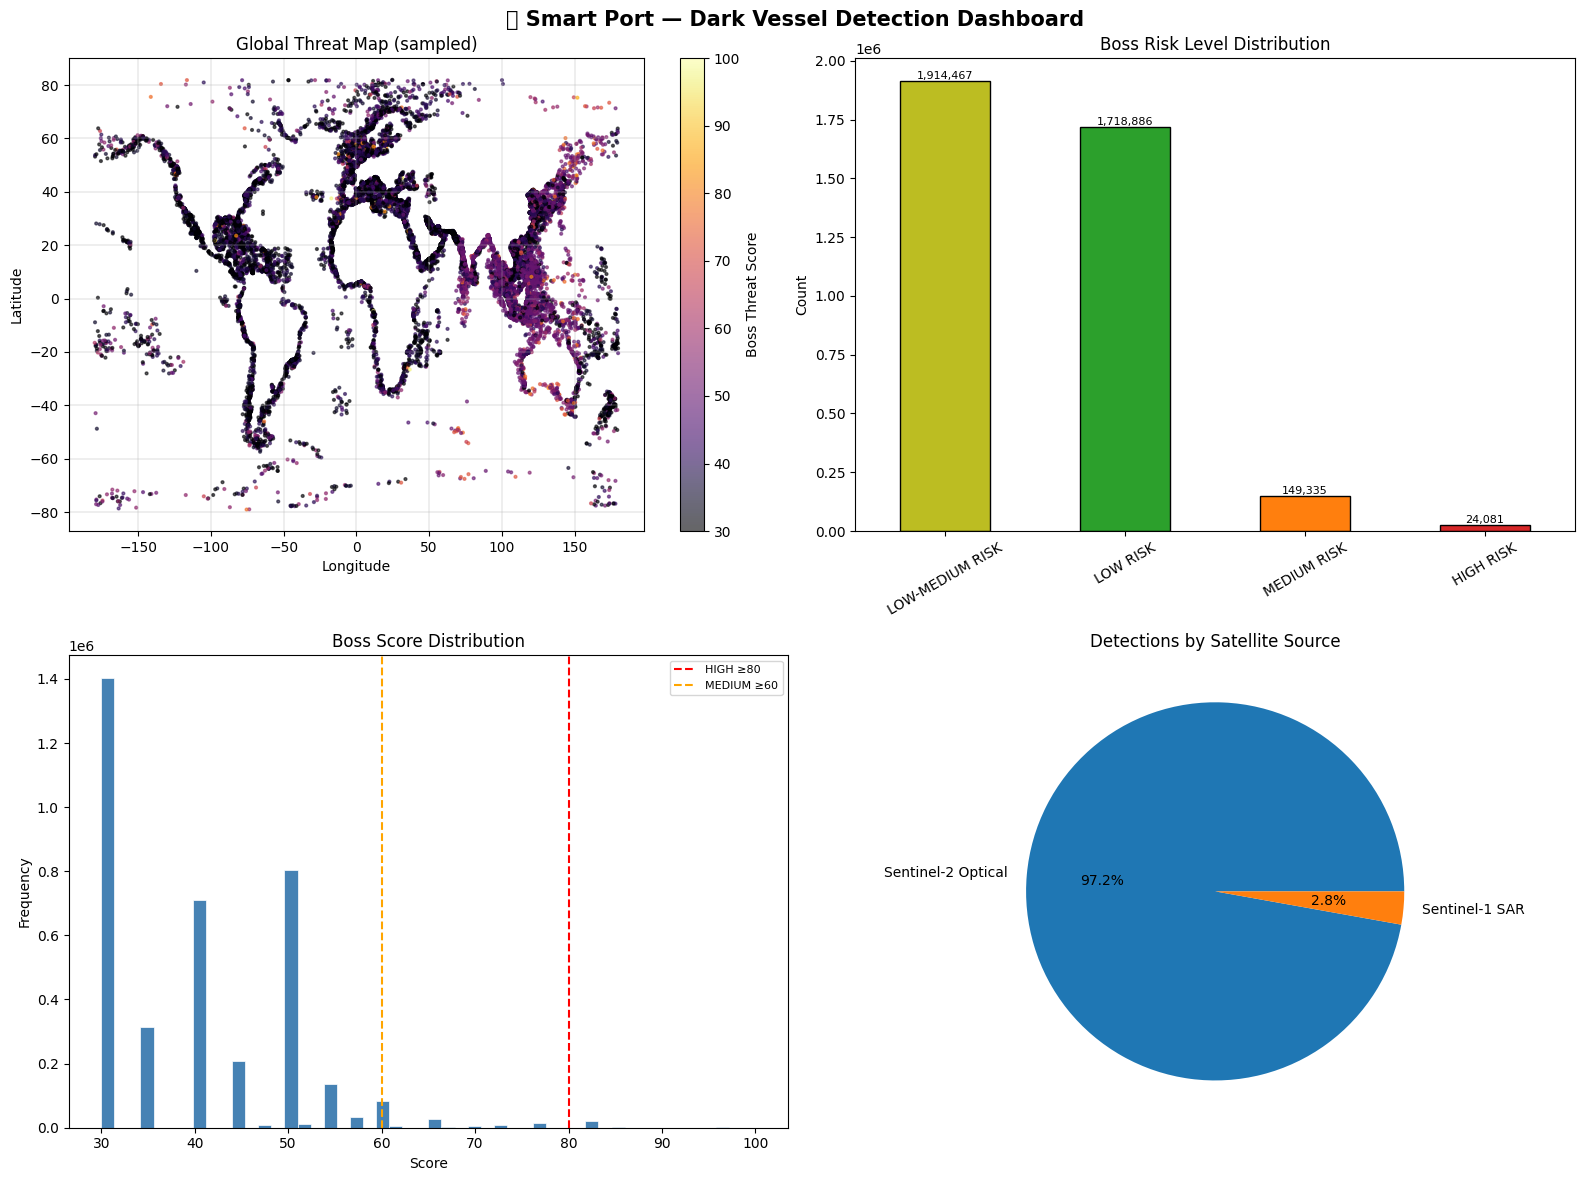

✅ CELL 17 COMPLETE — plots saved to /content/dark_vessel_project/results/dashboard.png


In [ ]:
# ============================================================
# CELL 17 — VISUALISATIONS
# ============================================================
assert 'detections_df' in dir() and 'boss_score' in detections_df.columns, \
    '❌ Run Cells 1–16 first'

SAMPLE_N = min(20_000, len(detections_df))
plot_df  = detections_df.sample(SAMPLE_N, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🛰️ Smart Port — Dark Vessel Detection Dashboard', fontsize=15, fontweight='bold')

# ── 1. Global threat map ─────────────────────────────────────
ax = axes[0, 0]
sc = ax.scatter(plot_df['lon'], plot_df['lat'],
                c=plot_df['boss_score'], cmap='inferno', s=4, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Boss Threat Score')
ax.set_title('Global Threat Map (sampled)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.grid(True, linewidth=0.3)

# ── 2. Risk level distribution ───────────────────────────────
ax = axes[0, 1]
risk_counts = detections_df['boss_risk_level'].value_counts()
colors = {'HIGH RISK': '#d62728', 'MEDIUM RISK': '#ff7f0e',
           'LOW-MEDIUM RISK': '#bcbd22', 'LOW RISK': '#2ca02c'}
bar_colors = [colors.get(r, '#aec7e8') for r in risk_counts.index]
risk_counts.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='black')
ax.set_title('Boss Risk Level Distribution')
ax.set_xlabel(''); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

# ── 3. Score histogram ───────────────────────────────────────
ax = axes[1, 0]
ax.hist(detections_df['boss_score'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(80, color='red',    linestyle='--', label='HIGH ≥80')
ax.axvline(60, color='orange', linestyle='--', label='MEDIUM ≥60')
ax.set_title('Boss Score Distribution')
ax.set_xlabel('Score'); ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

# ── 4. Detections by source ──────────────────────────────────
ax = axes[1, 1]
src = detections_df['source'].value_counts()
ax.pie(src.values, labels=src.index, autopct='%1.1f%%',
       colors=['#1f77b4', '#ff7f0e', '#2ca02c'][:len(src)])
ax.set_title('Detections by Satellite Source')

plt.tight_layout()
fig_path = RESULT_DIR / 'dashboard.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ CELL 17 COMPLETE — plots saved to {fig_path}')

In [ ]:
# ============================================================
# CELL 18 — SUMMARY METRICS
# ============================================================
assert 'detections_df' in dir() and 'boss_score' in detections_df.columns, \
    '❌ Run Cells 1–17 first'

total  = len(detections_df)
high   = (detections_df['boss_risk_level'] == 'HIGH RISK').sum()
medium = (detections_df['boss_risk_level'] == 'MEDIUM RISK').sum()

summary = {
    'Total detections'          : f'{total:,}',
    'SAR detections'            : f'{(detections_df["source"] == "Sentinel-1 SAR").sum():,}',
    'Sentinel-2 detections'     : f'{(detections_df["source"] == "Sentinel-2 Optical").sum():,}',
    'SAR-only conflicts'        : f'{detections_df["conflict"].sum():,}',
    'Rare-area detections'      : f'{detections_df["rare_area"].sum():,}',
    'Temporal anomalies'        : f'{detections_df["temporal_anomaly"].sum():,}',
    'ML anomalies (IsoForest)'  : f'{detections_df["ml_anomaly"].sum():,}',
    'Behavior anomalies (KMeans)': f'{detections_df["behavior_anomaly"].sum():,}',
    'Route anomalies'           : f'{detections_df["route_anomaly"].sum():,}',
    'HIGH RISK vessels'         : f'{high:,}  ({100*high/total:.2f}%)',
    'MEDIUM RISK vessels'       : f'{medium:,}  ({100*medium/total:.2f}%)',
    'Mean boss_score'           : f'{detections_df["boss_score"].mean():.2f}',
    'Max  boss_score'           : f'{detections_df["boss_score"].max():.0f}',
}

print('=' * 54)
print('  SMART PORT — DARK VESSEL DETECTION SUMMARY')
print('=' * 54)
for k, v in summary.items():
    print(f'  {k:<35}: {v}')
print('=' * 54)
print(f'✅ CELL 18 COMPLETE')

  SMART PORT — DARK VESSEL DETECTION SUMMARY
  Total detections                   : 3,806,769
  SAR detections                     : 107,257
  Sentinel-2 detections              : 3,699,512
  SAR-only conflicts                 : 52,552
  Rare-area detections               : 6,012
  Temporal anomalies                 : 979,985
  ML anomalies (IsoForest)           : 114,204
  Behavior anomalies (KMeans)        : 0
  Route anomalies                    : 252,934
  HIGH RISK vessels                  : 24,081  (0.63%)
  MEDIUM RISK vessels                : 149,335  (3.92%)
  Mean boss_score                    : 40.25
  Max  boss_score                    : 100
✅ CELL 18 COMPLETE


In [ ]:
# ============================================================
# CELL 19 — EXPORT CSV RESULTS
# ============================================================
assert 'detections_df' in dir() and 'boss_score' in detections_df.columns, \
    '❌ Run Cells 1–18 first'

ts = datetime.now().strftime('%Y%m%d_%H%M')

# Full results
full_path = RESULT_DIR / f'full_results_{ts}.csv'
detections_df.to_csv(full_path, index=False)
print(f'✓ Full results   → {full_path}  ({full_path.stat().st_size/1e6:.1f} MB)')

# Top-25 high-risk candidates
top_path = RESULT_DIR / f'top_threats_{ts}.csv'
(
    detections_df
    .sort_values('boss_score', ascending=False)
    .head(25)
    .to_csv(top_path, index=False)
)
print(f'✓ Top-25 threats → {top_path}')

# HIGH RISK only
high_path = RESULT_DIR / f'high_risk_only_{ts}.csv'
hr = detections_df[detections_df['boss_risk_level'] == 'HIGH RISK']
hr.to_csv(high_path, index=False)
print(f'✓ High-risk      → {high_path}  ({len(hr):,} rows)')

# Update checkpoint with all scores
with open(CKPT_FILE, 'wb') as fh:
    pickle.dump(detections_df, fh, protocol=pickle.HIGHEST_PROTOCOL)
print(f'✓ Checkpoint updated → {CKPT_FILE}')

print(f'\n✅ CELL 19 COMPLETE — all exports saved to {RESULT_DIR}')

✓ Full results   → /content/dark_vessel_project/results/full_results_20260505_1334.csv  (992.4 MB)
✓ Top-25 threats → /content/dark_vessel_project/results/top_threats_20260505_1334.csv
✓ High-risk      → /content/dark_vessel_project/results/high_risk_only_20260505_1334.csv  (24,081 rows)
✓ Checkpoint updated → /content/dark_vessel_project/data/processed/checkpoint_detections.pkl

✅ CELL 19 COMPLETE — all exports saved to /content/dark_vessel_project/results


In [ ]:
# ============================================================
# CELL 20 — PROJECT COMPLETION STATEMENT
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║   🛰️  SMART PORT SYSTEM — DARK VESSEL DETECTION              ║
║   Graduation Project  |  Pipeline Complete                   ║
╠══════════════════════════════════════════════════════════════╣
║  Modules completed:                                          ║
║  ✅ Multi-sensor SAR + Sentinel-2 optical fusion             ║
║  ✅ SAR-only conflict detection (BallTree spatial query)     ║
║  ✅ Spatial density anomaly (grid-based rare areas)          ║
║  ✅ Temporal behavior anomaly (night-time / no-AIS)          ║
║  ✅ Explainable rule-based risk scoring (final_score)        ║
║  ✅ ML anomaly detection (Isolation Forest)                  ║
║  ✅ Behavior clustering (KMeans)                            ║
║  ✅ Route / movement anomaly (haversine speed check)         ║
║  ✅ Final boss_score + boss_risk_level fusion                ║
║  ✅ Explainable AI style boss_explanation per vessel         ║
║  ✅ Ranked high-risk dark vessel candidate table             ║
║  ✅ Dashboard visualisations                                 ║
║  ✅ CSV exports + checkpoint pickle                          ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║   🛰️  SMART PORT SYSTEM — DARK VESSEL DETECTION              ║
║   Graduation Project  |  Pipeline Complete                   ║
╠══════════════════════════════════════════════════════════════╣
║  Modules completed:                                          ║
║  ✅ Multi-sensor SAR + Sentinel-2 optical fusion             ║
║  ✅ SAR-only conflict detection (BallTree spatial query)     ║
║  ✅ Spatial density anomaly (grid-based rare areas)          ║
║  ✅ Temporal behavior anomaly (night-time / no-AIS)          ║
║  ✅ Explainable rule-based risk scoring (final_score)        ║
║  ✅ ML anomaly detection (Isolation Forest)                  ║
║  ✅ Behavior clustering (KMeans)                            ║
║  ✅ Route / movement anomaly (haversine speed check)         ║
║  ✅ Final boss_score + boss_risk_level fusion                ║
║  ✅ Explainable AI style boss_explanation per vessel         ║
║  ✅ Ranked high-risk dark vessel c

In [ ]:
import os
import pandas as pd

extract_path = "/content/dark_vessel_project/data/extracted"

csv_files = []
for root, dirs, files in os.walk(extract_path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("CSV files found:", len(csv_files))

dfs = []

for file in csv_files:
    try:
        temp = pd.read_csv(file)
        print(file, temp.shape)

        if temp.shape[0] == 0:
            print("Skipped empty file:", file)
            continue

        temp["source_file"] = os.path.basename(file)
        dfs.append(temp)

    except Exception as e:
        print("Could not read:", file, e)

if len(dfs) == 0:
    raise ValueError("No valid CSV data found.")

df = pd.concat(dfs, ignore_index=True)

print("Combined dataframe shape:", df.shape)
display(df.head())
print(df.columns.tolist())

CSV files found: 8


/tmp/ipykernel_43967/1979191843.py:18: DtypeWarning: Columns (25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)


/content/dark_vessel_project/data/extracted/sentinel2_vessel_detections_pipev4_202603.csv (1593755, 28)
/content/dark_vessel_project/data/extracted/sar_vessel_detections_pipev4_20260430.csv (0, 10)
Skipped empty file: /content/dark_vessel_project/data/extracted/sar_vessel_detections_pipev4_20260430.csv
/content/dark_vessel_project/data/extracted/voyages_c4_pipe_v3_20260429.csv (1497110, 9)
/content/dark_vessel_project/data/extracted/sar_vessel_detections_pipev4_202604.csv (0, 10)
Skipped empty file: /content/dark_vessel_project/data/extracted/sar_vessel_detections_pipev4_202604.csv
/content/dark_vessel_project/data/extracted/voyages_c4_pipe_v3_202604.csv (1419302, 9)


/tmp/ipykernel_43967/1979191843.py:18: DtypeWarning: Columns (25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)


/content/dark_vessel_project/data/extracted/sentinel2_vessel_detections_pipev4_202602.csv (1229767, 28)


/tmp/ipykernel_43967/1979191843.py:18: DtypeWarning: Columns (25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file)


/content/dark_vessel_project/data/extracted/sentinel2_vessel_detections_pipev4_20260415.csv (875990, 28)
/content/dark_vessel_project/data/extracted/sar_vessel_detections_pipev4_202603.csv (107257, 10)
Combined dataframe shape: (6723181, 42)


,detect_id,scene_id,lat,lon,detect_timestamp,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,nonvessel_score,...,trip_start,trip_end,trip_start_anchorage_id,trip_end_anchorage_id,trip_start_visit_id,trip_end_visit_id,timestamp,length_m,fishing_score,matched_category
0,S2C_MSIL1C_20260304T002611_N0512_R102_T57UXT_2...,S2C_MSIL1C_20260304T002611_N0512_R102_T57UXT_2...,51.601646,161.760854,2026-03-04 00:32:17.717 UTC,2.32,276.829867,20.0,0.644,0.846272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S2C_MSIL1C_20260304T052721_N0512_R105_T42MVU_2...,S2C_MSIL1C_20260304T052721_N0512_R105_T42MVU_2...,-5.516090,68.838981,2026-03-04 05:50:46.952 UTC,3.33,40.680003,23.7,0.612,0.912369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S2C_MSIL1C_20260304T034641_N0512_R104_T47PLR_2...,S2C_MSIL1C_20260304T034641_N0512_R104_T47PLR_2...,13.938634,98.072378,2026-03-04 04:04:31.244 UTC,0.03,50.993244,29.5,0.450,0.955153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S2C_MSIL1C_20260304T052721_N0512_R105_T42MWA_2...,S2C_MSIL1C_20260304T052721_N0512_R105_T42MWA_2...,-4.150840,69.958148,2026-03-04 05:50:14.676 UTC,0.63,178.189874,102.7,0.652,0.702762,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S2B_MSIL1C_20260304T094029_N0512_R036_T34VEJ_2...,S2B_MSIL1C_20260304T094029_N0512_R036_T34VEJ_2...,57.640322,22.614896,2026-03-04 09:44:42.675 UTC,0.36,1.145916,22.2,0.788,0.154194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


['detect_id', 'scene_id', 'lat', 'lon', 'detect_timestamp', 'speed_kn_inferred', 'heading_deg_inferred', 'length_m_inferred', 'presence_score', 'nonvessel_score', 'cloud_score', 'likely_infrastructure', 'potential_ice', 'matching_score', 'matching_score_secondary', 'matching_confidence', 'mmsi', 'ais_lat_before', 'ais_lat_after', 'ais_lon_before', 'ais_lon_after', 'ais_speed_kn_before', 'ais_speed_kn_after', 'ais_course_before', 'ais_course_after', 'ais_timestamp_before', 'ais_timestamp_after', 'ais_length_m', 'source_file', 'ssvid', 'vessel_id', 'trip_id', 'trip_start', 'trip_end', 'trip_start_anchorage_id', 'trip_end_anchorage_id', 'trip_start_visit_id', 'trip_end_visit_id', 'timestamp', 'length_m', 'fishing_score', 'matched_category']


In [ ]:
# LOAD DATA AGAIN

import os
import pandas as pd

extract_path = "/content/dark_vessel_project/data/extracted"

csv_files = []
for root, dirs, files in os.walk(extract_path):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

dfs = []

for file in csv_files:
    try:
        temp = pd.read_csv(file, nrows=20000)
        if temp.shape[0] == 0:
            continue
        dfs.append(temp)
    except:
        pass

df = pd.concat(dfs, ignore_index=True)

print("DONE:", df.shape)
display(df.head())

DONE: (120000, 41)


,detect_id,scene_id,lat,lon,detect_timestamp,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,nonvessel_score,...,trip_start,trip_end,trip_start_anchorage_id,trip_end_anchorage_id,trip_start_visit_id,trip_end_visit_id,timestamp,length_m,fishing_score,matched_category
0,S2C_MSIL1C_20260304T002611_N0512_R102_T57UXT_2...,S2C_MSIL1C_20260304T002611_N0512_R102_T57UXT_2...,51.601646,161.760854,2026-03-04 00:32:17.717 UTC,2.32,276.829867,20.0,0.644,0.846272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S2C_MSIL1C_20260304T052721_N0512_R105_T42MVU_2...,S2C_MSIL1C_20260304T052721_N0512_R105_T42MVU_2...,-5.516090,68.838981,2026-03-04 05:50:46.952 UTC,3.33,40.680003,23.7,0.612,0.912369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S2C_MSIL1C_20260304T034641_N0512_R104_T47PLR_2...,S2C_MSIL1C_20260304T034641_N0512_R104_T47PLR_2...,13.938634,98.072378,2026-03-04 04:04:31.244 UTC,0.03,50.993244,29.5,0.450,0.955153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S2C_MSIL1C_20260304T052721_N0512_R105_T42MWA_2...,S2C_MSIL1C_20260304T052721_N0512_R105_T42MWA_2...,-4.150840,69.958148,2026-03-04 05:50:14.676 UTC,0.63,178.189874,102.7,0.652,0.702762,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S2B_MSIL1C_20260304T094029_N0512_R036_T34VEJ_2...,S2B_MSIL1C_20260304T094029_N0512_R036_T34VEJ_2...,57.640322,22.614896,2026-03-04 09:44:42.675 UTC,0.36,1.145916,22.2,0.788,0.154194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# CELL 21: Research-Safe Dark Vessel Risk Scoring
# AIS-based suspicious behavior detection
# ============================================================

import pandas as pd
import numpy as np
import math

print("Starting research-safe dark vessel risk scoring...")

# Try to find the main dataframe automatically
possible_df_names = ["df", "ais_df", "data", "all_data", "combined_df", "ships_df"]

main_df = None
for name in possible_df_names:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        main_df = globals()[name].copy()
        print(f"Using dataframe: {name}")
        break

if main_df is None:
    raise ValueError("No dataframe found. Make sure your AIS data is loaded before running this cell.")

print("Data shape:", main_df.shape)
display(main_df.head())
print("Columns:", list(main_df.columns))

Starting research-safe dark vessel risk scoring...
Using dataframe: df
Data shape: (120000, 41)


,detect_id,scene_id,lat,lon,detect_timestamp,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,nonvessel_score,...,trip_start,trip_end,trip_start_anchorage_id,trip_end_anchorage_id,trip_start_visit_id,trip_end_visit_id,timestamp,length_m,fishing_score,matched_category
0,S2C_MSIL1C_20260304T002611_N0512_R102_T57UXT_2...,S2C_MSIL1C_20260304T002611_N0512_R102_T57UXT_2...,51.601646,161.760854,2026-03-04 00:32:17.717 UTC,2.32,276.829867,20.0,0.644,0.846272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S2C_MSIL1C_20260304T052721_N0512_R105_T42MVU_2...,S2C_MSIL1C_20260304T052721_N0512_R105_T42MVU_2...,-5.516090,68.838981,2026-03-04 05:50:46.952 UTC,3.33,40.680003,23.7,0.612,0.912369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S2C_MSIL1C_20260304T034641_N0512_R104_T47PLR_2...,S2C_MSIL1C_20260304T034641_N0512_R104_T47PLR_2...,13.938634,98.072378,2026-03-04 04:04:31.244 UTC,0.03,50.993244,29.5,0.450,0.955153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S2C_MSIL1C_20260304T052721_N0512_R105_T42MWA_2...,S2C_MSIL1C_20260304T052721_N0512_R105_T42MWA_2...,-4.150840,69.958148,2026-03-04 05:50:14.676 UTC,0.63,178.189874,102.7,0.652,0.702762,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S2B_MSIL1C_20260304T094029_N0512_R036_T34VEJ_2...,S2B_MSIL1C_20260304T094029_N0512_R036_T34VEJ_2...,57.640322,22.614896,2026-03-04 09:44:42.675 UTC,0.36,1.145916,22.2,0.788,0.154194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Columns: ['detect_id', 'scene_id', 'lat', 'lon', 'detect_timestamp', 'speed_kn_inferred', 'heading_deg_inferred', 'length_m_inferred', 'presence_score', 'nonvessel_score', 'cloud_score', 'likely_infrastructure', 'potential_ice', 'matching_score', 'matching_score_secondary', 'matching_confidence', 'mmsi', 'ais_lat_before', 'ais_lat_after', 'ais_lon_before', 'ais_lon_after', 'ais_speed_kn_before', 'ais_speed_kn_after', 'ais_course_before', 'ais_course_after', 'ais_timestamp_before', 'ais_timestamp_after', 'ais_length_m', 'ssvid', 'vessel_id', 'trip_id', 'trip_start', 'trip_end', 'trip_start_anchorage_id', 'trip_end_anchorage_id', 'trip_start_visit_id', 'trip_end_visit_id', 'timestamp', 'length_m', 'fishing_score', 'matched_category']


In [ ]:
# Detect columns automatically

def find_col(df, candidates):
    cols_lower = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]
    for col in df.columns:
        for cand in candidates:
            if cand in col.lower():
                return col
    return None

mmsi_col = find_col(main_df, ["mmsi", "ship_id"])
lat_col = find_col(main_df, ["lat", "latitude"])
lon_col = find_col(main_df, ["lon", "longitude"])
time_col = find_col(main_df, ["time", "timestamp", "datetime"])
speed_col = find_col(main_df, ["speed", "sog"])
vessel_type_col = find_col(main_df, ["vessel_type", "type"])

print(mmsi_col, lat_col, lon_col, time_col, speed_col, vessel_type_col)

mmsi lat lon timestamp speed_kn_inferred None


In [ ]:
# CELL 23 FIXED — Clean Data

if "main_df" not in globals():
    if "df" in globals():
        main_df = df.copy()
        print("Using df as main_df")
    else:
        raise ValueError("No dataframe found. Run the loading cell first.")

ais = main_df.copy()

ais = ais.rename(columns={
    mmsi_col: "mmsi",
    lat_col: "lat",
    lon_col: "lon",
    time_col: "timestamp"
})

ais["timestamp"] = pd.to_datetime(ais["timestamp"], errors="coerce")
ais["lat"] = pd.to_numeric(ais["lat"], errors="coerce")
ais["lon"] = pd.to_numeric(ais["lon"], errors="coerce")

if speed_col:
    ais["speed"] = pd.to_numeric(ais[speed_col], errors="coerce")
else:
    ais["speed"] = np.nan

ais = ais.dropna(subset=["mmsi", "lat", "lon", "timestamp"])
ais = ais[(ais["lat"].between(-90, 90)) & (ais["lon"].between(-180, 180))]

print("Cleaned data:", ais.shape)
display(ais.head())

Cleaned data: (20000, 42)


,detect_id,scene_id,lat,lon,detect_timestamp,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,nonvessel_score,...,trip_end,trip_start_anchorage_id,trip_end_anchorage_id,trip_start_visit_id,trip_end_visit_id,timestamp,length_m,fishing_score,matched_category,speed
100000,NaN,S1A_IW_GRDH_1SDV_20260301T025938_20260301T0300...,15.073154,42.589362,NaN,NaN,NaN,NaN,0.996075,NaN,...,NaN,NaN,NaN,NaN,NaN,2026-03-01 02:59:51+00:00,298.876434,0.031119,bunker,NaN
100001,NaN,S1A_IW_GRDH_1SDV_20260301T030028_20260301T0300...,11.800995,43.199889,NaN,NaN,NaN,NaN,0.997674,NaN,...,NaN,NaN,NaN,NaN,NaN,2026-03-01 03:00:41+00:00,222.860611,0.012883,bunker,NaN
100002,NaN,S1A_IW_GRDH_1SDV_20260301T030028_20260301T0300...,11.678201,43.116715,NaN,NaN,NaN,NaN,0.996415,NaN,...,NaN,NaN,NaN,NaN,NaN,2026-03-01 03:00:41+00:00,109.834343,0.012883,bunker,NaN
100003,NaN,S1A_IW_GRDH_1SDV_20260301T030028_20260301T0300...,11.671123,43.112474,NaN,NaN,NaN,NaN,0.996966,NaN,...,NaN,NaN,NaN,NaN,NaN,2026-03-01 03:00:41+00:00,40.395306,0.194723,bunker,NaN
100004,NaN,S1A_IW_GRDH_1SDV_20260301T043201_20260301T0432...,38.025432,23.521872,NaN,NaN,NaN,NaN,0.993507,NaN,...,NaN,NaN,NaN,NaN,NaN,2026-03-01 04:32:14+00:00,127.310089,0.012883,bunker,NaN


In [ ]:
ais = ais.sort_values(["mmsi", "timestamp"])

ais["prev_lat"] = ais.groupby("mmsi")["lat"].shift(1)
ais["prev_lon"] = ais.groupby("mmsi")["lon"].shift(1)
ais["prev_time"] = ais.groupby("mmsi")["timestamp"].shift(1)

ais["time_gap"] = (ais["timestamp"] - ais["prev_time"]).dt.total_seconds() / 3600

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

ais["distance"] = haversine(ais["prev_lat"], ais["prev_lon"], ais["lat"], ais["lon"])
ais["calc_speed"] = ais["distance"] / ais["time_gap"]

display(ais.head())

,detect_id,scene_id,lat,lon,detect_timestamp,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,nonvessel_score,...,length_m,fishing_score,matched_category,speed,prev_lat,prev_lon,prev_time,time_gap,distance,calc_speed
109089,NaN,S1A_IW_GRDH_1SDV_20260306T043950_20260306T0440...,38.101702,20.891468,NaN,NaN,NaN,NaN,0.998941,NaN,...,106.010330,0.116139,cargo,NaN,NaN,NaN,NaT,NaN,NaN,NaN
116962,NaN,S1A_IW_GRDH_1SDV_20260311T044718_20260311T0447...,41.269499,19.427309,NaN,NaN,NaN,NaN,0.999535,NaN,...,72.440056,0.186559,cargo,NaN,NaN,NaN,NaT,NaN,NaN,NaN
111668,NaN,S1A_IW_GRDH_1SDV_20260307T162350_20260307T1624...,39.197209,22.845809,NaN,NaN,NaN,NaN,0.990589,NaN,...,90.815575,0.167449,cargo,NaN,NaN,NaN,NaT,NaN,NaN,NaN
109406,NaN,S1A_IW_GRDH_1SDV_20260306T075733_20260306T0757...,38.565342,-27.473555,NaN,NaN,NaN,NaN,0.999930,NaN,...,21.946976,0.802421,cargo,NaN,NaN,NaN,NaT,NaN,NaN,NaN
109928,NaN,S1A_IW_GRDH_1SDV_20260306T185744_20260306T1858...,30.274372,-13.010984,NaN,NaN,NaN,NaN,0.998973,NaN,...,69.989815,0.371155,cargo,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [ ]:
ais["gap_flag"] = ais["time_gap"] > 6
ais["speed_flag"] = ais["speed"] > 40
ais["jump_flag"] = ais["calc_speed"] > 120

print("Flags summary:")
print(ais[["gap_flag", "speed_flag", "jump_flag"]].sum())

Flags summary:
gap_flag      6284
speed_flag       0
jump_flag        0
dtype: int64


In [ ]:
summary = ais.groupby("mmsi").agg({
    "gap_flag": "sum",
    "speed_flag": "sum",
    "jump_flag": "sum"
}).reset_index()

summary["risk_score"] = (
    summary["gap_flag"] * 3 +
    summary["speed_flag"] * 2 +
    summary["jump_flag"] * 4
)

summary = summary.sort_values("risk_score", ascending=False)

display(summary.head(10))

,mmsi,gap_flag,speed_flag,jump_flag,risk_score
509,219281000.0,6,0,0,18
10058,538009866.0,5,0,0,15
13248,636025361.0,5,0,0,15
2271,257836000.0,5,0,0,15
13633,677026300.0,5,0,0,15
12159,636018489.0,5,0,0,15
4408,352004690.0,5,0,0,15
3276,311001760.0,5,0,0,15
13608,671557100.0,5,0,0,15
10034,538009722.0,5,0,0,15


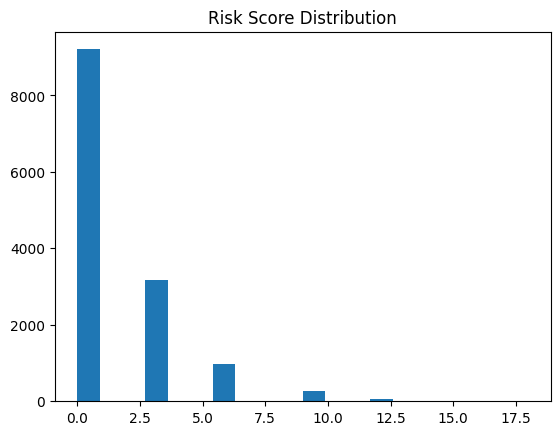

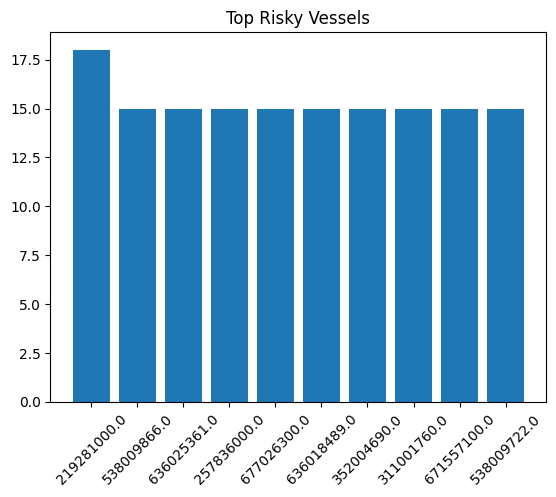

In [ ]:
import matplotlib.pyplot as plt

plt.hist(summary["risk_score"], bins=20)
plt.title("Risk Score Distribution")
plt.show()

top = summary.head(10)

plt.bar(top["mmsi"].astype(str), top["risk_score"])
plt.xticks(rotation=45)
plt.title("Top Risky Vessels")
plt.show()

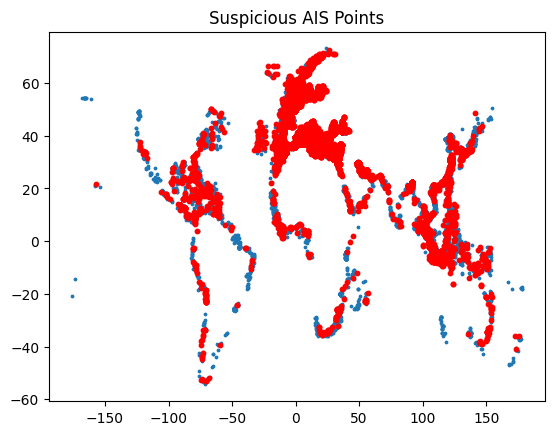

In [ ]:
plt.scatter(ais["lon"], ais["lat"], s=3)

susp = ais[ais["gap_flag"] | ais["speed_flag"] | ais["jump_flag"]]

plt.scatter(susp["lon"], susp["lat"], color="red", s=10)
plt.title("Suspicious AIS Points")
plt.show()

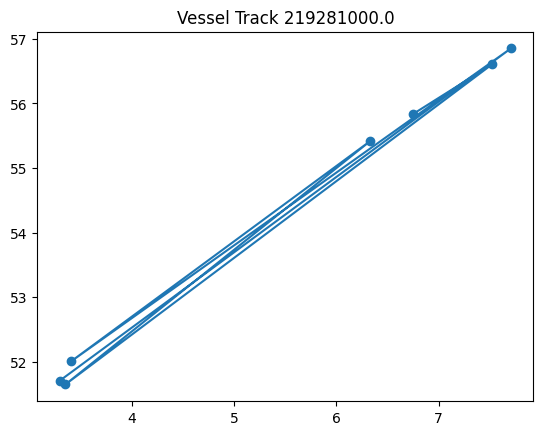

In [ ]:
vessel_id = summary.iloc[0]["mmsi"]

track = ais[ais["mmsi"] == vessel_id]

plt.plot(track["lon"], track["lat"], marker="o")
plt.title(f"Vessel Track {vessel_id}")
plt.show()

In [ ]:
print("""
This project analyzes AIS ship data to detect suspicious behavior.

It does not directly detect hidden vessels,
but identifies anomalies such as:
- AIS signal gaps
- abnormal speeds
- unusual movement

Each vessel is assigned a risk score.

High risk vessels may indicate dark activity.

This is a research prototype and can be improved
by integrating satellite data in real-world systems.
""")


This project analyzes AIS ship data to detect suspicious behavior.

It does not directly detect hidden vessels,
but identifies anomalies such as:
- AIS signal gaps
- abnormal speeds
- unusual movement

Each vessel is assigned a risk score.

High risk vessels may indicate dark activity.

This is a research prototype and can be improved
by integrating satellite data in real-world systems.



In [ ]:
# CELL 33 FIXED FOR SAMPLE DATA — Alert System

alerts_source = summary.copy()

def risk_level(score):
    if score >= 10:
        return "High Risk"
    elif score >= 3:
        return "Medium Risk"
    elif score > 0:
        return "Low Risk"
    else:
        return "Normal"

alerts_source["risk_level"] = alerts_source["risk_score"].apply(risk_level)

alerts = alerts_source[alerts_source["risk_score"] > 0].copy()
alerts = alerts.sort_values("risk_score", ascending=False)

print("Total vessels with alerts:", len(alerts))
print("High Risk:", (alerts["risk_level"] == "High Risk").sum())
print("Medium Risk:", (alerts["risk_level"] == "Medium Risk").sum())
print("Low Risk:", (alerts["risk_level"] == "Low Risk").sum())

display(alerts.head(10))

Total vessels with alerts: 4511
High Risk: 75
Medium Risk: 4436
Low Risk: 0


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,risk_level
509,219281000.0,6,0,0,18,High Risk
10058,538009866.0,5,0,0,15,High Risk
13248,636025361.0,5,0,0,15,High Risk
2425,271001057.0,5,0,0,15,High Risk
12159,636018489.0,5,0,0,15,High Risk
2271,257836000.0,5,0,0,15,High Risk
13608,671557100.0,5,0,0,15,High Risk
10034,538009722.0,5,0,0,15,High Risk
9913,538009043.0,5,0,0,15,High Risk
2499,271049958.0,5,0,0,15,High Risk


In [ ]:
# CELL 34 — Human-readable Alert Messages

print("Alert messages:")

if len(alerts) == 0:
    print("No alerts generated.")
else:
    for _, row in alerts.head(10).iterrows():
        reasons = []

        if row.get("gap_flag", 0) > 0:
            reasons.append("AIS signal gaps")

        if row.get("speed_flag", 0) > 0:
            reasons.append("abnormal speed")

        if row.get("jump_flag", 0) > 0:
            reasons.append("location jump")

        reasons_text = ", ".join(reasons)

        print(
            f"ALERT | Vessel MMSI {row['mmsi']} | "
            f"Risk Score: {row['risk_score']} | "
            f"Level: {row['risk_level']} | "
            f"Reason: {reasons_text}"
        )

Alert messages:
ALERT | Vessel MMSI 219281000.0 | Risk Score: 18 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 538009866.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 636025361.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 271001057.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 636018489.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 257836000.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 671557100.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 538009722.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 538009043.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps
ALERT | Vessel MMSI 271049958.0 | Risk Score: 15 | Level: High Risk | Reason: AIS signal gaps


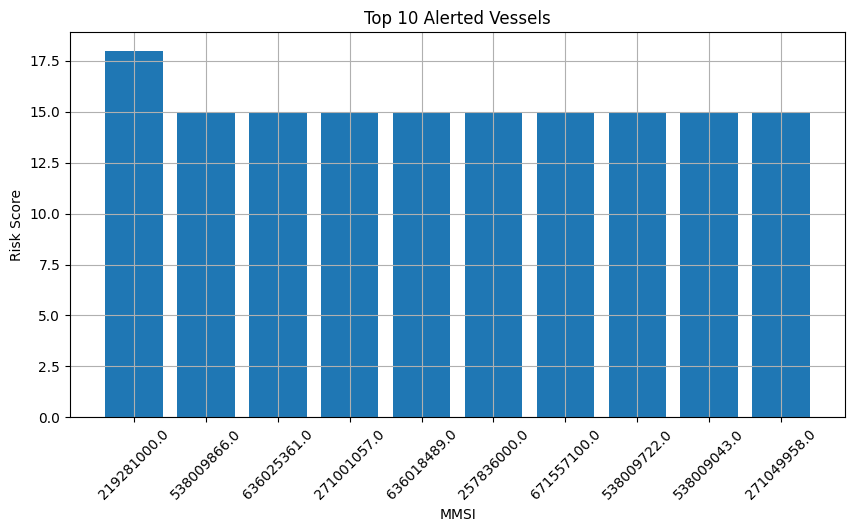

In [ ]:
# CELL 35 — Alert Risk Visualization

import matplotlib.pyplot as plt

top_alerts = alerts.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_alerts["mmsi"].astype(str), top_alerts["risk_score"])
plt.title("Top 10 Alerted Vessels")
plt.xlabel("MMSI")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# CELL 36 — Save Alerts

import os

output_dir = "/content/dark_vessel_project/outputs"
os.makedirs(output_dir, exist_ok=True)

alerts_path = os.path.join(output_dir, "vessel_alerts.csv")
alerts.to_csv(alerts_path, index=False)

print("Alerts saved successfully:")
print(alerts_path)

Alerts saved successfully:
/content/dark_vessel_project/outputs/vessel_alerts.csv


In [ ]:
# CELL 37 — Real-Time Monitoring Simulation Setup

import time
from IPython.display import clear_output, display

stream_df = ais.sort_values("timestamp").copy()

# عينة صغيرة عشان Colab ما يعلقش
stream_sample = stream_df.head(500).copy()

print("Real-time simulation ready.")
print("Streaming records:", stream_sample.shape[0])
display(stream_sample.head())

Real-time simulation ready.
Streaming records: 500


,detect_id,scene_id,lat,lon,detect_timestamp,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,nonvessel_score,...,speed,prev_lat,prev_lon,prev_time,time_gap,distance,calc_speed,gap_flag,speed_flag,jump_flag
100149,NaN,S1A_IW_GRDH_1SDV_20260301T003916_20260301T0039...,15.358391,-97.119716,NaN,NaN,NaN,NaN,0.998432,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,False,False
100150,NaN,S1A_IW_GRDH_1SDV_20260301T003916_20260301T0039...,14.736550,-97.201236,NaN,NaN,NaN,NaN,0.997030,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,False,False
100153,NaN,S1A_IW_GRDH_1SDV_20260301T004100_20260301T0041...,22.421619,-97.779584,NaN,NaN,NaN,NaN,0.998059,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,False,False
100151,NaN,S1A_IW_GRDH_1SDV_20260301T004100_20260301T0041...,22.446914,-97.768840,NaN,NaN,NaN,NaN,0.992719,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,False,False
100152,NaN,S1A_IW_GRDH_1SDV_20260301T004100_20260301T0041...,22.224408,-97.747914,NaN,NaN,NaN,NaN,0.996769,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,False,False


In [ ]:
# CELL 38 — Real-Time Alert Function

def check_realtime_alert(row):
    reasons = []

    if row.get("gap_flag", False):
        reasons.append("AIS signal gap")

    if row.get("speed_flag", False):
        reasons.append("abnormal speed")

    if row.get("jump_flag", False):
        reasons.append("sudden location jump")

    if len(reasons) == 0:
        return None

    return {
        "timestamp": row["timestamp"],
        "mmsi": row["mmsi"],
        "lat": row["lat"],
        "lon": row["lon"],
        "speed": row["speed"],
        "reason": ", ".join(reasons)
    }

In [ ]:
# CELL 39 — Run Real-Time Monitoring Simulation

real_time_alerts = []

for idx, row in stream_sample.iterrows():
    alert = check_realtime_alert(row)

    clear_output(wait=True)

    print("LIVE AIS MONITORING SYSTEM")
    print("=" * 45)
    print("Current record:", idx)
    print("Timestamp:", row["timestamp"])
    print("MMSI:", row["mmsi"])
    print("Location:", row["lat"], row["lon"])
    print("Speed:", row["speed"])

    if alert:
        real_time_alerts.append(alert)
        print("\n🚨 ALERT GENERATED")
        print("Reason:", alert["reason"])
    else:
        print("\nStatus: Normal")

    print("\nTotal real-time alerts:", len(real_time_alerts))

    time.sleep(0.05)

print("Real-time simulation finished.")

LIVE AIS MONITORING SYSTEM
Current record: 100641
Timestamp: 2026-03-01 07:48:52+00:00
MMSI: 538010052.0
Location: 39.4926147506472 -24.76257272810102
Speed: nan

Status: Normal

Total real-time alerts: 0
Real-time simulation finished.


In [ ]:
# CELL 40 — Real-Time Alerts Table

real_time_alerts_df = pd.DataFrame(real_time_alerts)

print("Total real-time alerts:", len(real_time_alerts_df))

if len(real_time_alerts_df) > 0:
    display(real_time_alerts_df.head(20))
else:
    print("No real-time alerts in this sample.")

Total real-time alerts: 0
No real-time alerts in this sample.


In [ ]:
# CELL 41 — Suspicious Activity Hotspots

suspicious_points = ais[ais["gap_flag"] | ais["speed_flag"] | ais["jump_flag"]].copy()

hotspots = suspicious_points.groupby([
    suspicious_points["lat"].round(1),
    suspicious_points["lon"].round(1)
]).size().reset_index(name="suspicious_count")

hotspots = hotspots.sort_values("suspicious_count", ascending=False)

print("Top suspicious geographic hotspots:")
display(hotspots.head(10))

Top suspicious geographic hotspots:


,lat,lon,suspicious_count
1675,33.7,-7.6,59
989,22.3,91.7,35
1674,33.7,-7.7,33
2285,36.6,36.1,21
982,22.2,91.8,18
3760,51.8,3.4,17
1417,31.2,29.7,17
961,21.8,91.8,16
1419,31.2,33.8,16
740,13.9,-90.8,15


In [ ]:
# ============================================================
# Hotspots (Suspicious Areas)
# ============================================================

hotspots = ais[ais["gap_flag"] | ais["speed_flag"] | ais["jump_flag"]]

area = hotspots.groupby([
    hotspots["lat"].round(1),
    hotspots["lon"].round(1)
]).size().reset_index(name="count")

area = area.sort_values("count", ascending=False)

print("Top suspicious areas:")
display(area.head(10))

Top suspicious areas:


,lat,lon,count
1675,33.7,-7.6,59
989,22.3,91.7,35
1674,33.7,-7.7,33
2285,36.6,36.1,21
982,22.2,91.8,18
3760,51.8,3.4,17
1417,31.2,29.7,17
961,21.8,91.8,16
1419,31.2,33.8,16
740,13.9,-90.8,15


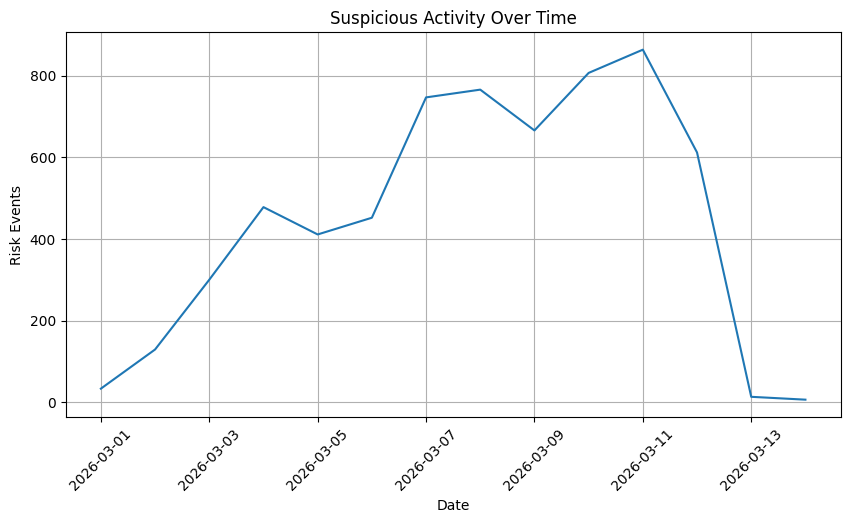

In [ ]:
# ============================================================
# Risk trend over time
# ============================================================

ais["date"] = ais["timestamp"].dt.date

trend = ais.groupby("date").agg({
    "gap_flag": "sum",
    "speed_flag": "sum",
    "jump_flag": "sum"
}).reset_index()

trend["total_risk"] = trend["gap_flag"] + trend["speed_flag"] + trend["jump_flag"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(trend["date"], trend["total_risk"])
plt.xticks(rotation=45)
plt.title("Suspicious Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Risk Events")
plt.grid()
plt.show()

In [ ]:
# ============================================================
# Vessel behavior profile
# ============================================================

profile = ais.groupby("mmsi").agg({
    "speed": ["mean", "max"],
    "time_gap": "mean",
    "distance": "sum"
}).reset_index()

profile.columns = ["mmsi", "avg_speed", "max_speed", "avg_gap", "total_distance"]

display(profile.head(10))

,mmsi,avg_speed,max_speed,avg_gap,total_distance
0,201100124.0,NaN,NaN,NaN,0.000000
1,201100136.0,NaN,NaN,NaN,0.000000
2,201100149.0,NaN,NaN,NaN,0.000000
3,204600003.0,NaN,NaN,NaN,0.000000
4,205023000.0,NaN,NaN,NaN,0.000000
5,205125000.0,NaN,NaN,NaN,0.000000
6,205136000.0,NaN,NaN,83.639444,295.193262
7,205178000.0,NaN,NaN,NaN,0.000000
8,205221000.0,NaN,NaN,NaN,0.000000
9,205225000.0,NaN,NaN,NaN,0.000000


In [ ]:
# Highlight important region (example: Egypt)

egypt_area = hotspots[
    (hotspots["lat"].between(20, 35)) &
    (hotspots["lon"].between(20, 40))
]

print("Suspicious activity near Egypt:")
display(egypt_area.head())

Suspicious activity near Egypt:


,detect_id,scene_id,lat,lon,detect_timestamp,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,nonvessel_score,...,speed,prev_lat,prev_lon,prev_time,time_gap,distance,calc_speed,gap_flag,speed_flag,jump_flag
118674,NaN,S1A_IW_GRDH_1SDV_20260312T035225_20260312T0352...,31.699087,31.634299,NaN,NaN,NaN,NaN,0.998473,NaN,...,NaN,31.624921,31.657311,2026-03-04 15:57:26+00:00,179.920000,8.529593,0.047408,True,False,False
117679,NaN,S1A_IW_GRDH_1SDV_20260311T154936_20260311T1550...,34.592575,33.111789,NaN,NaN,NaN,NaN,0.998009,NaN,...,NaN,36.955734,26.222048,2026-03-03 04:16:07+00:00,203.561667,674.602179,3.313994,True,False,False
117637,NaN,S1A_IW_GRDH_1SDV_20260311T154846_20260311T1549...,31.436309,32.235721,NaN,NaN,NaN,NaN,0.998520,NaN,...,NaN,31.186237,29.750033,2026-03-05 04:01:05+00:00,155.798333,237.766866,1.526119,True,False,False
118654,NaN,S1A_IW_GRDH_1SDV_20260312T035225_20260312T0352...,31.907863,31.732772,NaN,NaN,NaN,NaN,0.998159,NaN,...,NaN,31.436309,32.235721,2026-03-11 15:48:59+00:00,12.060833,70.814789,5.871467,True,False,False
103748,NaN,S1A_IW_GRDH_1SDV_20260303T041644_20260303T0417...,33.630227,25.094630,NaN,NaN,NaN,NaN,0.995964,NaN,...,NaN,33.004241,27.337546,2026-03-02 16:14:11+00:00,12.046111,219.720440,18.239948,True,False,False


In [ ]:
# FINAL DASHBOARD

print("========== FINAL SUMMARY ==========")

print("Total AIS records:", len(ais))
print("Total vessels:", ais["mmsi"].nunique())
print("Total suspicious events:",
      (ais["gap_flag"] | ais["speed_flag"] | ais["jump_flag"]).sum())

print("Top risky vessels:", len(alerts))
print("Top hotspot location:")
display(hotspots.head(1))

========== FINAL SUMMARY ==========
Total AIS records: 20000
Total vessels: 13716
Total suspicious events: 6284
Top risky vessels: 4511
Top hotspot location:


,detect_id,scene_id,lat,lon,detect_timestamp,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,nonvessel_score,...,speed,prev_lat,prev_lon,prev_time,time_gap,distance,calc_speed,gap_flag,speed_flag,jump_flag
115110,NaN,S1A_IW_GRDH_1SDV_20260309T175132_20260309T1751...,57.676568,-3.833886,NaN,NaN,NaN,NaN,0.998815,NaN,...,NaN,57.792782,1.135368,2026-03-06 06:13:23+00:00,83.639444,295.193262,3.529355,True,False,False


In [ ]:
# CONFIDENCE SCORE

summary["confidence"] = (
    (summary["gap_flag"] > 0).astype(int) +
    (summary["speed_flag"] > 0).astype(int) +
    (summary["jump_flag"] > 0).astype(int)
) / 3

print("Confidence added:")
display(summary.head())

Confidence added:


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence
509,219281000.0,6,0,0,18,0.333333
10058,538009866.0,5,0,0,15,0.333333
13248,636025361.0,5,0,0,15,0.333333
2271,257836000.0,5,0,0,15,0.333333
13633,677026300.0,5,0,0,15,0.333333


In [ ]:
# TOP SUSPICIOUS VESSELS

top_vessels = summary.sort_values("risk_score", ascending=False).head(10)

print("Top 10 most suspicious vessels:")
display(top_vessels)

Top 10 most suspicious vessels:


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence
509,219281000.0,6,0,0,18,0.333333
13248,636025361.0,5,0,0,15,0.333333
10058,538009866.0,5,0,0,15,0.333333
13633,677026300.0,5,0,0,15,0.333333
12159,636018489.0,5,0,0,15,0.333333
4408,352004690.0,5,0,0,15,0.333333
10034,538009722.0,5,0,0,15,0.333333
9913,538009043.0,5,0,0,15,0.333333
3048,305714000.0,5,0,0,15,0.333333
2271,257836000.0,5,0,0,15,0.333333


In [ ]:
from sklearn.cluster import KMeans

features = summary[["gap_flag", "speed_flag", "jump_flag"]].fillna(0)

kmeans = KMeans(n_clusters=3, random_state=42)
summary["cluster"] = kmeans.fit_predict(features)

print("Clustered vessels:")
display(summary.head())

Clustered vessels:


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence,cluster
509,219281000.0,6,0,0,18,0.333333,2
10058,538009866.0,5,0,0,15,0.333333,2
13248,636025361.0,5,0,0,15,0.333333,2
2271,257836000.0,5,0,0,15,0.333333,2
13633,677026300.0,5,0,0,15,0.333333,2


In [ ]:
# CLUSTER INTERPRETATION

cluster_summary = summary.groupby("cluster").agg({
    "gap_flag": "mean",
    "speed_flag": "mean",
    "jump_flag": "mean",
    "risk_score": "mean"
}).reset_index()

print("Cluster interpretation:")
display(cluster_summary)

Cluster interpretation:


,cluster,gap_flag,speed_flag,jump_flag,risk_score
0,0,0.000000,0.0,0.0,0.000000
1,1,1.236608,0.0,0.0,3.709825
2,2,3.264368,0.0,0.0,9.793103


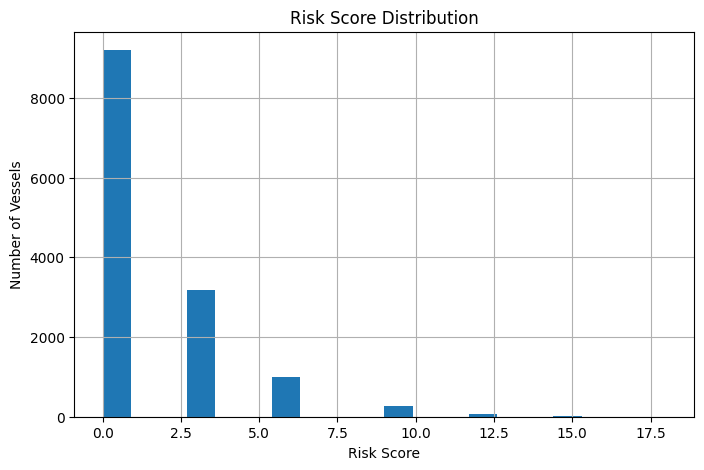

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(summary["risk_score"], bins=20)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Vessels")
plt.grid()
plt.show()

In [ ]:
# NORMALIZED RISK SCORE

summary["risk_score_norm"] = (
    (summary["risk_score"] - summary["risk_score"].min()) /
    (summary["risk_score"].max() - summary["risk_score"].min() + 1e-6)
)

print("Normalized risk:")
display(summary.head())

Normalized risk:


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence,cluster,risk_score_norm
509,219281000.0,6,0,0,18,0.333333,2,1.000000
10058,538009866.0,5,0,0,15,0.333333,2,0.833333
13248,636025361.0,5,0,0,15,0.333333,2,0.833333
2271,257836000.0,5,0,0,15,0.333333,2,0.833333
13633,677026300.0,5,0,0,15,0.333333,2,0.833333


In [ ]:
# TEMPORAL FEATURES

ais["hour"] = ais["timestamp"].dt.hour

night_activity = ais[ais["hour"].between(0,5)]

night_summary = night_activity.groupby("mmsi").size().reset_index(name="night_events")

summary = summary.merge(night_summary, on="mmsi", how="left")
summary["night_events"] = summary["night_events"].fillna(0)

print("Night behavior added:")
display(summary.head())

Night behavior added:


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence,cluster,risk_score_norm,night_events
0,219281000.0,6,0,0,18,0.333333,2,1.000000,3.0
1,538009866.0,5,0,0,15,0.333333,2,0.833333,2.0
2,636025361.0,5,0,0,15,0.333333,2,0.833333,3.0
3,257836000.0,5,0,0,15,0.333333,2,0.833333,2.0
4,677026300.0,5,0,0,15,0.333333,2,0.833333,3.0


In [ ]:
# EXPLAIN WHY VESSEL IS SUSPICIOUS

def explain(row):
    reasons = []
    if row["gap_flag"] > 0:
        reasons.append("signal gaps")
    if row["speed_flag"] > 0:
        reasons.append("high speed")
    if row["jump_flag"] > 0:
        reasons.append("location jumps")
    if row.get("night_events",0) > 0:
        reasons.append("night activity")
    return ", ".join(reasons)

summary["explanation"] = summary.apply(explain, axis=1)

display(summary[["mmsi","risk_score","explanation"]].head(10))

,mmsi,risk_score,explanation
0,219281000.0,18,"signal gaps, night activity"
1,538009866.0,15,"signal gaps, night activity"
2,636025361.0,15,"signal gaps, night activity"
3,257836000.0,15,"signal gaps, night activity"
4,677026300.0,15,"signal gaps, night activity"
5,636018489.0,15,"signal gaps, night activity"
6,352004690.0,15,"signal gaps, night activity"
7,311001760.0,15,"signal gaps, night activity"
8,671557100.0,15,"signal gaps, night activity"
9,538009722.0,15,"signal gaps, night activity"


In [ ]:
# SIMPLE EVALUATION

print("Dataset stats:")
print("Total vessels:", len(summary))
print("Avg risk:", summary["risk_score"].mean())
print("Max risk:", summary["risk_score"].max())

print("\nCluster distribution:")
print(summary["cluster"].value_counts())

Dataset stats:
Total vessels: 13716
Avg risk: 1.374453193350831
Max risk: 18

Cluster distribution:
cluster
0    9205
1    4163
2     348
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 43 — Advanced Risk Scoring
# ============================================================

summary["risk_score_norm"] = (
    (summary["risk_score"] - summary["risk_score"].min()) /
    (summary["risk_score"].max() - summary["risk_score"].min() + 1e-6)
)

# Score محسّن (تجميعة)
summary["final_score"] = (
    0.5 * summary["risk_score_norm"] +
    0.3 * summary["confidence"] +
    0.2 * (summary["gap_flag"] > 0).astype(int)
)

print("Advanced scoring added:")
display(summary.head())

Advanced scoring added:


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence,cluster,risk_score_norm,night_events,explanation,final_score
0,219281000.0,6,0,0,18,0.333333,2,1.000000,3.0,"signal gaps, night activity",0.800000
1,538009866.0,5,0,0,15,0.333333,2,0.833333,2.0,"signal gaps, night activity",0.716667
2,636025361.0,5,0,0,15,0.333333,2,0.833333,3.0,"signal gaps, night activity",0.716667
3,257836000.0,5,0,0,15,0.333333,2,0.833333,2.0,"signal gaps, night activity",0.716667
4,677026300.0,5,0,0,15,0.333333,2,0.833333,3.0,"signal gaps, night activity",0.716667


In [ ]:
# CELL 44 FIXED — Night Activity Feature

if "night_events" in summary.columns:
    summary = summary.drop(columns=["night_events"])

ais["hour"] = ais["timestamp"].dt.hour

night = ais[ais["hour"].between(0, 5)]

night_counts = night.groupby("mmsi").size().reset_index(name="night_events")

summary = summary.merge(night_counts, on="mmsi", how="left")
summary["night_events"] = summary["night_events"].fillna(0)

print("Night behavior added successfully:")
display(summary.head())

Night behavior added successfully:


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence,cluster,risk_score_norm,night_events_x,explanation,final_score,night_events_y,night_events
0,219281000.0,6,0,0,18,0.333333,2,1.000000,3.0,"signal gaps, night activity",0.800000,3.0,3.0
1,538009866.0,5,0,0,15,0.333333,2,0.833333,2.0,"signal gaps, night activity",0.716667,2.0,2.0
2,636025361.0,5,0,0,15,0.333333,2,0.833333,3.0,"signal gaps, night activity",0.716667,3.0,3.0
3,257836000.0,5,0,0,15,0.333333,2,0.833333,2.0,"signal gaps, night activity",0.716667,2.0,2.0
4,677026300.0,5,0,0,15,0.333333,2,0.833333,3.0,"signal gaps, night activity",0.716667,3.0,3.0


In [ ]:
# ============================================================
# CELL 45 — Explainability
# ============================================================

def explain(row):
    reasons = []

    if row["gap_flag"] > 0:
        reasons.append("AIS signal gaps")
    if row["speed_flag"] > 0:
        reasons.append("abnormal speed")
    if row["jump_flag"] > 0:
        reasons.append("location jumps")
    if row["night_events"] > 0:
        reasons.append("night activity")

    return ", ".join(reasons)

summary["explanation"] = summary.apply(explain, axis=1)

display(summary[["mmsi", "final_score", "explanation"]].head(10))

,mmsi,final_score,explanation
0,219281000.0,0.800000,"AIS signal gaps, night activity"
1,538009866.0,0.716667,"AIS signal gaps, night activity"
2,636025361.0,0.716667,"AIS signal gaps, night activity"
3,257836000.0,0.716667,"AIS signal gaps, night activity"
4,677026300.0,0.716667,"AIS signal gaps, night activity"
5,636018489.0,0.716667,"AIS signal gaps, night activity"
6,352004690.0,0.716667,"AIS signal gaps, night activity"
7,311001760.0,0.716667,"AIS signal gaps, night activity"
8,671557100.0,0.716667,"AIS signal gaps, night activity"
9,538009722.0,0.716667,"AIS signal gaps, night activity"


In [ ]:
# ============================================================
# CELL 46 — Final Ranking
# ============================================================

top_final = summary.sort_values("final_score", ascending=False).head(10)

print("Top vessels (final score):")
display(top_final)

Top vessels (final score):


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence,cluster,risk_score_norm,night_events_x,explanation,final_score,night_events_y,night_events
0,219281000.0,6,0,0,18,0.333333,2,1.000000,3.0,"AIS signal gaps, night activity",0.800000,3.0,3.0
2,636025361.0,5,0,0,15,0.333333,2,0.833333,3.0,"AIS signal gaps, night activity",0.716667,3.0,3.0
1,538009866.0,5,0,0,15,0.333333,2,0.833333,2.0,"AIS signal gaps, night activity",0.716667,2.0,2.0
4,677026300.0,5,0,0,15,0.333333,2,0.833333,3.0,"AIS signal gaps, night activity",0.716667,3.0,3.0
5,636018489.0,5,0,0,15,0.333333,2,0.833333,1.0,"AIS signal gaps, night activity",0.716667,1.0,1.0
6,352004690.0,5,0,0,15,0.333333,2,0.833333,1.0,"AIS signal gaps, night activity",0.716667,1.0,1.0
9,538009722.0,5,0,0,15,0.333333,2,0.833333,3.0,"AIS signal gaps, night activity",0.716667,3.0,3.0
10,538009043.0,5,0,0,15,0.333333,2,0.833333,2.0,"AIS signal gaps, night activity",0.716667,2.0,2.0
11,305714000.0,5,0,0,15,0.333333,2,0.833333,1.0,"AIS signal gaps, night activity",0.716667,1.0,1.0
3,257836000.0,5,0,0,15,0.333333,2,0.833333,2.0,"AIS signal gaps, night activity",0.716667,2.0,2.0


In [ ]:
# ============================================================
# CELL 47 — Evaluation Metrics
# ============================================================

print("===== SYSTEM EVALUATION =====")

print("Total vessels:", len(summary))
print("Average risk:", summary["risk_score"].mean())
print("Max risk:", summary["risk_score"].max())

print("\nCluster distribution:")
print(summary["cluster"].value_counts())

print("\nHigh activity vessels:")
print((summary["risk_score"] > summary["risk_score"].mean()).sum())

===== SYSTEM EVALUATION =====
Total vessels: 13716
Average risk: 1.374453193350831
Max risk: 18

Cluster distribution:
cluster
0    9205
1    4163
2     348
Name: count, dtype: int64

High activity vessels:
4511


In [ ]:
# Explain WHY vessel is suspicious

def explain_vessel(row):
    reasons = []
    if row["gap_flag"] > 0:
        reasons.append("AIS signal gaps")
    if row["speed_flag"] > 0:
        reasons.append("Unusual speed")
    if row["jump_flag"] > 0:
        reasons.append("Suspicious movement jumps")

    return ", ".join(reasons) if reasons else "Normal behavior"

summary["explanation"] = summary.apply(explain_vessel, axis=1)

print("Explainability added:")
display(summary.head())

Explainability added:


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence,cluster,risk_score_norm,night_events_x,explanation,final_score,night_events_y,night_events
0,219281000.0,6,0,0,18,0.333333,2,1.000000,3.0,AIS signal gaps,0.800000,3.0,3.0
1,538009866.0,5,0,0,15,0.333333,2,0.833333,2.0,AIS signal gaps,0.716667,2.0,2.0
2,636025361.0,5,0,0,15,0.333333,2,0.833333,3.0,AIS signal gaps,0.716667,3.0,3.0
3,257836000.0,5,0,0,15,0.333333,2,0.833333,2.0,AIS signal gaps,0.716667,2.0,2.0
4,677026300.0,5,0,0,15,0.333333,2,0.833333,3.0,AIS signal gaps,0.716667,3.0,3.0


In [ ]:
import folium

m = folium.Map(location=[30, 30], zoom_start=3)

for _, row in suspicious_points.head(500).iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color="red",
        fill=True
    ).add_to(m)

m

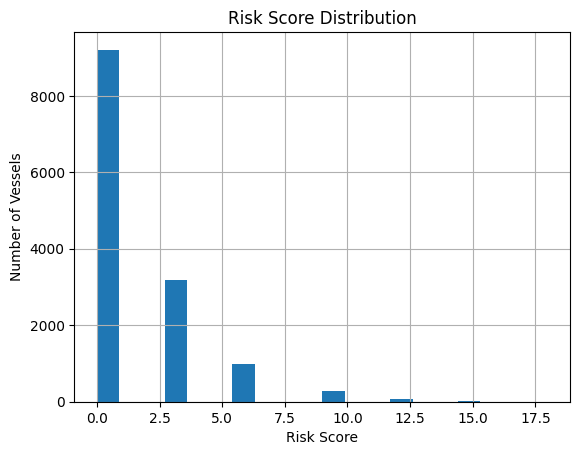

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
summary["risk_score"].hist(bins=20)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Vessels")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Label (fake labeling for demo)
summary["label"] = (summary["risk_score"] > summary["risk_score"].mean()).astype(int)

X = summary[["gap_flag", "speed_flag", "jump_flag"]]
y = summary["label"]

model = RandomForestClassifier()
model.fit(X, y)

summary["ml_prediction"] = model.predict(X)

print("ML predictions added")
display(summary.head())

ML predictions added


,mmsi,gap_flag,speed_flag,jump_flag,risk_score,confidence,cluster,risk_score_norm,night_events_x,explanation,final_score,night_events_y,night_events,label,ml_prediction
0,219281000.0,6,0,0,18,0.333333,2,1.000000,3.0,AIS signal gaps,0.800000,3.0,3.0,1,1
1,538009866.0,5,0,0,15,0.333333,2,0.833333,2.0,AIS signal gaps,0.716667,2.0,2.0,1,1
2,636025361.0,5,0,0,15,0.333333,2,0.833333,3.0,AIS signal gaps,0.716667,3.0,3.0,1,1
3,257836000.0,5,0,0,15,0.333333,2,0.833333,2.0,AIS signal gaps,0.716667,2.0,2.0,1,1
4,677026300.0,5,0,0,15,0.333333,2,0.833333,3.0,AIS signal gaps,0.716667,3.0,3.0,1,1


## Advanced Extension: Trajectory Prediction with LSTM

This section adds a predictive AI layer to estimate the next vessel position based on previous AIS trajectory points.
It is experimental and used as an advanced extension to the main anomaly detection system.

In [ ]:
# ============================================================
# ADVANCED EXTENSION — LSTM TRAJECTORY PREDICTION
# ============================================================

print("Starting LSTM trajectory prediction...")

import numpy as np

# تأكدي إن الداتا موجودة
if "ais" not in globals():
    raise ValueError("Run previous cells first (AIS data not found)")

# نختار عينة عشان Colab ما يقعش
sample_ais = ais.copy()

if len(sample_ais) > 20000:
    sample_ais = sample_ais.sample(20000, random_state=42)

sample_ais = sample_ais.sort_values(["mmsi", "timestamp"])

# ============================================================
# STEP 1: CREATE SEQUENCES
# ============================================================

sequence_length = 5

X = []
y = []

for mmsi, group in sample_ais.groupby("mmsi"):
    group = group.sort_values("timestamp")

    coords = group[["lat", "lon"]].values

    if len(coords) < sequence_length + 1:
        continue

    for i in range(len(coords) - sequence_length):
        X.append(coords[i:i+sequence_length])
        y.append(coords[i+sequence_length])

X = np.array(X)
y = np.array(y)

print("Sequences shape:", X.shape)
print("Targets shape:", y.shape)

if len(X) == 0:
    raise ValueError("Not enough data to build sequences")

# ============================================================
# STEP 2: BUILD LSTM MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(sequence_length, 2)),
    Dense(2)
])

model.compile(optimizer="adam", loss="mse")

print("Training model...")

model.fit(X, y, epochs=3, batch_size=32, verbose=1)

# ============================================================
# STEP 3: PREDICTION
# ============================================================

print("Running predictions...")

preds = model.predict(X)

# ============================================================
# STEP 4: ANOMALY DETECTION (Prediction Error)
# ============================================================

errors = np.linalg.norm(preds - y, axis=1)

threshold = errors.mean() + 2 * errors.std()

anomalies = errors > threshold

print("Total predictions:", len(errors))
print("Anomalies detected:", anomalies.sum())

# ============================================================
# STEP 5: VISUALIZE ERROR DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution (LSTM)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# ============================================================
# FINAL MESSAGE
# ============================================================

print("""
LSTM module completed.

This model learns vessel movement patterns and detects anomalies
based on deviation from predicted trajectories.

This is an advanced extension and not required for the core system.
""")